# **Spatial Machine Learning Analysis of Pediatric Asthma Drivers in South Carolina:** Environmental and Social Determinants of Health
**Author:** Melissa Callahan

**Affiliation:** College of Charleston; Graduate Program Data Science and Analytics 

**Objective:** This notebook aims to build a geospatial machine learning model to predict pediatric asthma burden across South Carolina’s 46 counties. It integrated environmental and atmospheric from 2016 to 2024, and socioeconomic data from 2023 and 2024.

This study integrates United States Environmental Protection Agency (EPA) sensor data with Centers for Disease Control and Prevention (CDC) social vulnerability and South Carolina health metrics to model pediatric asthma risk across 46 state counties. By utilizing Ordinary Kriging interpolation, Bayesian Ridge Regression, and engineered a Pediatric Housing Vulnerability composite feature: findings reveal that social vulnerability is a more dominant predictor of asthma outcomes than air quality alone, highlighting the double burden faced by South Carolina’s most vulnerable. 


## **Part 0:** Setup & Imports

In [1]:
# Set up to import all libraries for the project!!
# ---------- Core Data & System Tools ----------
import pandas as pd
import numpy as np
import glob
import os

# ---------- Visualization ----------
import matplotlib.pyplot as plt
import seaborn as sns
# Set the visual style for all plots
plt.style.use('seaborn-v0_8-whitegrid')

# ---------- Geospatial & Statistics ----------
from pykrige.ok import OrdinaryKriging
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# ---------- Scikit-Learn: Preprocessing & Model Selection ----------
from sklearn.model_selection import (
    train_test_split, 
    cross_val_predict, 
    cross_val_score, 
    LeaveOneOut, 
    GridSearchCV, 
    learning_curve
)

# ---------- Scikit-Learn: Models & Metrics ----------
from sklearn.linear_model import BayesianRidge, HuberRegressor, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# ---------- Model Interpretation & Inspection ----------
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# Finds home folder 
home = os.path.expanduser("~")

## **Part 1:** Data Acquisition & Sources

This project integrates environmental, demographic, and health datasets to analyze the correlation between air quality and pediatric asthma in South Carolina.
#### **1. Geospatial & Administrative References** 
* **EPA State and County Codes** || [Link](https://aqs.epa.gov/aqsweb/documents/codetables/states_and_counties.html)
    * *Role:* Provides the foundational mapping for FIPS codes, State/County names, and numeric codes to ensure consistency across disparate datasets!
* **U.S. Census Bureau Centeroids** || [Link](https://www.census.gov/geographies/reference-files.html)
    * *Role:* Used as the geographic "target variable" for spatial interpolation. This allows for estimating pollutant levels in the 26 South Carolina counties currently missing direct sensor data.
* **USDA Rural-Urban Continuum Codes (RUCC)** || [Link](https://www.ers.usda.gov/data-products/rural-urban-continuum-codes)
    * *Role:* Classifies counties into 9 distinct categories (Urban to Rural). This serves as a key covariate to control for population density and industrial activity.
#### **2. Environmental & Air Quality Data (2016–2024)**
* **EPA AirData (Pollutant Datasets)** || [Link](https://aqs.epa.gov/aqsweb/airdata/download_files.html)
    * *Parameters:* Ozone (O3), PM2.5, PM10, and Nitrogen Dioxide (NO2).
    * *Role:* Primary independent variables for assessing air pollution exposure.
* **NOAA Climate at a Glance (Temperature)** || [Link](https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/county/time-series/SC-091/tavg/1/0/2015-2025)
    * *Role:* Monthly median average temperatures by county on respiratory health.
#### **3. Health & Socioeconomic Indicators**
* **SC DPH Pediatric Asthma Rates** || [Link](https://dph.sc.gov/professionals/public-health-data/sc-tracking/tracking-asthma-dashboard)
    * *Source:* Cleaned data requested from SC Department of Public Health (SC DPH) via the Revenue and Fiscal Affairs Office (RFA).
    * *Metrics:* Crude rates per 10,000 population for ages 0–19.
    * *Role:* The primary dependent variable for the study.
* **CDC Environmental Justice Index (EJI) 2024** || [Link](https://www.atsdr.cdc.gov/place-health/php/eji/index.html), [Link 2](https://www.atsdr.cdc.gov/place-health/php/eji/eji-data-download.html) 
    * *Role:* Provides a composite score of cumulative impacts—including social vulnerability and environmental burden—to identify disproportionately affected communities.

In [ ]:
# ---------- Part 1.1: Loading EPA and Other Files ----------

# Base directory for all data folders
# Relative path: looks for a 'data' folder next to this notebook
base_path = os.path.join(os.getcwd(), "data")

# List of dataset folders to load (some contains multiple CSVs to combine)
datasets = ['epa_code', 'epa_no2_42602', 'epa_ozone_44201', 'epa_pm10_81102', 'epa_pm25_88101',
            'sc_centroids', 'eji_2024', 'scdph_asthma_rate']

# Dictionary to store the final DataFrame for each dataset
all_datasets = {}

# Loop through each dataset folder and load the CSV files
for folder in datasets:
    folder_path = os.path.join(base_path, folder)
    csv_files = glob.glob(os.path.join(folder_path, "*.csv"))                        # Find all CSVs inside specific folder
    if csv_files:
        combined_df = pd.concat(                                                    # Load and combine all CSVs in folder into one DataFrame
    [pd.read_csv(f, encoding='utf-8-sig', low_memory=False) for f in csv_files],    # Use utf-8-sig encoding to handle potential byte order marks, and low_memory=False to avoid dtype warnings
    ignore_index=True)
        all_datasets[folder] = combined_df
        print(f"Loaded {folder}: {len(csv_files)} file(s), {len(combined_df)} total rows")
    else:
        print(f"Check Again! No CSVs found in {folder}")

Loaded epa_code: 1 file(s), 3281 total rows
Loaded epa_no2_42602: 9 file(s), 1410068 total rows
Loaded epa_ozone_44201: 9 file(s), 3545548 total rows
Loaded epa_pm10_81102: 9 file(s), 1569793 total rows
Loaded epa_pm25_88101: 9 file(s), 6022224 total rows
Loaded sc_centroids: 1 file(s), 46 total rows
Loaded eji_2024: 1 file(s), 85188 total rows
Loaded scdph_asthma_rate: 1 file(s), 46 total rows


In [ ]:
# ---------- Part 1.2: Loading SC Temperature Datasets ----------

# Specific processing for NOAA Average Temperature files due to unique format
temp_folder = os.path.join(base_path, "noaa_avg_temp")
temp_files = glob.glob(os.path.join(temp_folder, '*.csv'))
temp_dfs = []

# Loop through each temperature file, extract county name, and load into a DataFrame.
for file in temp_files:
    try:
        # Extract county name (example 'Charleston' from 'Charleston_County_Avg_Temp')      # Can also by extracting metadata from NOAA header
        file_name = os.path.basename(file)
        county_name = file_name.split('_County_Avg_Temp_')[0].replace('_', ' ')             # Replace underscores with spaces for better readability

        # Read CSV: Skip the 2 lines of NOAA metadata at the top
        temp_df = pd.read_csv(file, skiprows=2, header=0, encoding='latin1')                # Using encoding='latin1' as it flagged special characters in the header

        # Standardize Columns
        temp_df.columns = ['Date', 'Avg_Temp']
        temp_df['County'] = county_name
        temp_df['Date'] = pd.to_datetime(temp_df['Date'], format='%Y%m')                    # Convert Date (Format is YYYYMM)
        
        temp_dfs.append(temp_df)                                                            # Append each temperature DataFrame to the list 
    except Exception as e:
        print(f"Error in {file_name}: {e}")

# Final concatenation of all temperature DataFrames into one main DataFrame
if temp_dfs:
    sc_temp_df = pd.concat(temp_dfs, ignore_index=True)
    print(f"Loaded sc_temp_df: {len(sc_temp_df)} rows across {len(temp_dfs)} counties.")
    print(sc_temp_df.head(3))
else:
    print("Check Again! No temperature files were successfully loaded.")

Loaded sc_temp_df: 6312 rows across 46 counties.
        Date  Avg_Temp      County
0 2015-01-01      40.6  Greenville
1 2015-02-01      36.9  Greenville
2 2015-03-01      53.6  Greenville


In [ ]:
# ---------- Part 1.3: Loading Urban Code Datasets ----------

# Specific processing for Urban Codes due to special characters and ensuring FIPS codes are properly formatted
urban_folder = os.path.join(base_path, "urban_code")
urban_files = glob.glob(os.path.join(urban_folder, '*.csv'))
urban_dfs = []

for f in urban_files:
    df = pd.read_csv(f, encoding='latin-1', low_memory=False)           # latin-1 handles the special characters in county names
    if 'FIPS' in df.columns:
        df['FIPS'] = df['FIPS'].astype(str).str.zfill(5)                # Ensure FIPS is a string with leading zeros (01001 vs 1001)
    urban_dfs.append(df)                                                # Append each urban code DataFrame to the list
combined_urban_df = pd.concat(urban_dfs, ignore_index=True)

print(f"Loaded combined_urban_df: {len(combined_urban_df)} rows.")
print(combined_urban_df.head(3))

Loaded combined_urban_df: 9703 rows.
    FIPS State     County_Name        Attribute  \
0  01001    AL  Autauga County  Population_2020   
1  01001    AL  Autauga County        RUCC_2023   
2  01001    AL  Autauga County      Description   

                                               Value  
0                                              58805  
1                                                  2  
2  Metro - Counties in metro areas of 250,000 to ...  


## **Part 2:** Clean/Prepare Datasets


### **Part 2.1:** Assign FIPS to Datasets

In [5]:
# ---------- Part 2.1.1: Establish FIPS Codes, Apply to SC Temperature Dataset ----------

# Extract dataset with all states and county codes
epa_states_and_counties_df = all_datasets['epa_code']

# Create FIPS by combining State Code and County Code (Example: State Code '45' + County Code '001' = FIPS '45001')
epa_states_and_counties_df['FIPS'] = (
    epa_states_and_counties_df['State Code'].astype(str).str.zfill(2) + 
    epa_states_and_counties_df['County Code'].astype(str).str.zfill(3))
print("FIPS created for epa_states_and_counties_df")
# epa_states_and_counties_df.head(1)

# Standardize County Names: lowercase for the merges
epa_states_and_counties_df['County Name'] = epa_states_and_counties_df['County Name'].str.lower()
sc_temp_df['County'] = sc_temp_df['County'].str.lower()

# Filter to South Carolina from epa_states_and_counties_df
sc_county_code_df = epa_states_and_counties_df[epa_states_and_counties_df['State Code'] == '45'][['County Name', 'FIPS']].copy()

# Merge to add FIPS into the SC Temperature Data via County Name!
sc_temp_with_fips = pd.merge(
    sc_temp_df,
    sc_county_code_df[['County Name', 'FIPS']],
    left_on='County', 
    right_on='County Name', 
    how='left') # Use a left join to retain all temperature records and only add the FIPS

# Clean up the county name column
sc_temp_with_fips.drop(columns=['County Name'], inplace=True)

# Checking to see if any FIPS codes are missing!
missing_fips = sc_temp_with_fips['FIPS'].isna().sum()
if missing_fips > 0:
    print(f"Check Again! {missing_fips} rows are missing FIPS codes! Check for naming mismatches?")
else:
    print("Yippee! All temperature rows have 5-digit FIPS code!")

# Check the results
print("\n--- SC Temperature with FIPS ---")
sc_temp_with_fips.head(2)

FIPS created for epa_states_and_counties_df
Yippee! All temperature rows have 5-digit FIPS code!

--- SC Temperature with FIPS ---


,Date,Avg_Temp,County,FIPS
0,2015-01-01,40.6,greenville,45045
1,2015-02-01,36.9,greenville,45045


In [6]:
# ---------- Part 2.1.2: Apply to SC Asthma Rate Dataset ----------

# Extract asthma dataset
asthma_df = all_datasets['scdph_asthma_rate']

# Standardize County Names, lowercase for the merges
asthma_df['GEOGRAPHY'] = asthma_df['GEOGRAPHY'].str.lower()

# Merge FIPS into the SC Asthma Data
sc_asthma_with_fips = pd.merge(
    asthma_df,
    sc_county_code_df[['County Name', 'FIPS']],
    left_on='GEOGRAPHY', 
    right_on='County Name', 
    how='left') # Use a left join to retain all asthma records and only add the FIPS

# Clean up the county name column
sc_asthma_with_fips.drop(columns=['GEOGRAPHY'], inplace=True)

# Checking to see if any FIPS codes are missing for Asthma!
missing_asthma_fips = sc_asthma_with_fips['FIPS'].isna().sum()
if missing_asthma_fips > 0:
    print(f"Check Again! {missing_asthma_fips} Asthma rows are missing FIPS codes! Check for naming mismatches?")
else:
    print("Yippee! All Asthma rows have a 5-digit FIPS code!")

# Show the results
print("\n--- SC Asthma with FIPS ---")
print(sc_asthma_with_fips.head(2))


Yippee! All Asthma rows have a 5-digit FIPS code!

--- SC Asthma with FIPS ---
                                  MEASURE       YEAR AGE GROUP  \
0  EMERGENCY DEPARTMENT VISITS FOR ASTHMA  2016-2024      0-19   
1  EMERGENCY DEPARTMENT VISITS FOR ASTHMA  2016-2024      0-19   

                           VALUE TYPE      VALUE County Name   FIPS  
0  CRUDE RATE (PER 10,000 POPULATION)  63.259784   abbeville  45001  
1  CRUDE RATE (PER 10,000 POPULATION)  33.246015       aiken  45003  


In [7]:
# ---------- Step 2.1.3: Establish FIPS Codes on EPA & EJI Datasets ----------

# Rename columns in EJI dataset to match the others for FIPS creation
if 'eji_2024' in all_datasets:
    all_datasets['eji_2024'].rename(
        columns={'STATEFP': 'State Code', 'COUNTYFP': 'County Code'}, 
        inplace=True)

# List of datasets
epa_eji = ['epa_no2_42602', 'epa_ozone_44201', 'epa_pm10_81102', 'epa_pm25_88101', 'eji_2024']

print("--- Creating FIPS for Pollutant Datasets ---")
for key in epa_eji:
    if key in all_datasets:
        df = all_datasets[key]
        df['FIPS'] = (
            df['State Code'].astype(str).str.zfill(2) + 
            df['County Code'].astype(str).str.zfill(3)
            )
        print(f"{key}: FIPS created! (Rows: {len(df)})")
    else:
        print(f"Check again... {key} not found in dictionary.")

print("\nYippee! EPA & EJI datasets now have FIPS columns!")

--- Creating FIPS for Pollutant Datasets ---
epa_no2_42602: FIPS created! (Rows: 1410068)
epa_ozone_44201: FIPS created! (Rows: 3545548)
epa_pm10_81102: FIPS created! (Rows: 1569793)
epa_pm25_88101: FIPS created! (Rows: 6022224)
eji_2024: FIPS created! (Rows: 85188)

Yippee! EPA & EJI datasets now have FIPS columns!


### **Part 2.2:** Filter and Clean EPA Datasets 

In [8]:
# ---------- Step 2.2.1: Prepare Counties for Interpolation and Aggregation ----------

# Target Data: South Carolina only
sc_target_counties = sc_county_code_df.copy()                           # sc_county_code_df from 2.1.1 already has the SC counties with FIPS codes, so we can use that directly for the target counties!

# Interpolation Data: SC (45) + Border States (GA=13, NC=37)
interp_counties = epa_states_and_counties_df[
    epa_states_and_counties_df['State Code'].isin(['45', '13', '37'])   # The spatial borders for calculations
].copy()

print(f"--> Aggregation (SC): {len(sc_target_counties)} counties")
print(f"--> Interpolation (SC, GA, NC): {len(interp_counties)} counties")

--> Aggregation (SC): 46 counties
--> Interpolation (SC, GA, NC): 305 counties


In [9]:
# ---------- Step 2.2.2: Filter US Datasets by Study Area  ----------

# The list of unique FIPS for the study area (SC, GA, NC)
study_area_fips = interp_counties['FIPS'].unique()

print(f"--- Filter rows for {len(study_area_fips)} Study Area Counties ---")
# Loop through each dataset and filter to only include rows where the FIPS code is in the study area (SC, GA, NC).
for key in epa_eji:                                                                                     # Will further filter EJI later!
    if key in all_datasets:                                                                             # Keep only the rows where the FIPS is in the study area
        all_datasets[key] = all_datasets[key][all_datasets[key]['FIPS'].isin(study_area_fips)].copy()   
        rows_remaining = len(all_datasets[key])                                                         # Calculate the number of rows remaining after filtering!
        print(f"{key} filtered: {rows_remaining:,} rows remain.")
    else:
        print(f"{key} not found in dictionary...")

--- Filter rows for 305 Study Area Counties ---
epa_no2_42602 filtered: 41,022 rows remain.
epa_ozone_44201 filtered: 172,939 rows remain.
epa_pm10_81102 filtered: 46,064 rows remain.
epa_pm25_88101 filtered: 369,465 rows remain.
eji_2024 filtered: 6,768 rows remain.


In [10]:
# ---------- Step 2.2.3: Feature Filter EPA Datasets ----------

# List of pollutant datasets to clean and filter for analysis
epa_pollutants = ['epa_no2_42602', 'epa_ozone_44201', 'epa_pm10_81102', 'epa_pm25_88101']

# Columns need for the analysis
cols_to_keep = ['FIPS', 'State Code', 'Date Local', 'Latitude', 'Longitude', 'Arithmetic Mean', 'AQI']

print("--- Cleaning & Column Reduction ---")
# Loop through each pollutant dataset, filter by AQI to keep only 24-HOUR summaries, keep only necessary features, standardize date format, and sort by FIPS then Date.
# Credit to Gemini for the original code structure, with adjustments for better error handling, readability, and to ensure we only keep the necessary columns that are common across all datasets!
for key in epa_pollutants:
    if key in all_datasets:
        df = all_datasets[key]

        # Filter by AQI: Drops the rows where AQI is null, which also keeps only the 24-HOUR summaries
        df = df.dropna(subset=['AQI']).copy()
        
        # Keep the necessary features (keep the columns that are common across all datasets to avoid errors!)
        existing_cols = [c for c in cols_to_keep if c in df.columns]
        df = df[existing_cols].copy()
        
        # Standardize Date
        df.rename(columns={'Date Local': 'Date'}, inplace=True)
        df['Date'] = pd.to_datetime(df['Date'], format='mixed')
        
        # Sort by FIPS then by Date
        df = df.sort_values(by=['FIPS', 'Date']).reset_index(drop=True)
        
        # Drop AQI now that the cleaning is done!
        df = df.drop(columns=['AQI'], errors='ignore')

        # Update the dictionary!
        all_datasets[key] = df
        print(f"{key} Cleaned: {len(df):,} rows.")

print("\nAll EPA datasets are cleaned and sorted!")

--- Cleaning & Column Reduction ---
epa_no2_42602 Cleaned: 41,022 rows.
epa_ozone_44201 Cleaned: 172,939 rows.
epa_pm10_81102 Cleaned: 46,064 rows.
epa_pm25_88101 Cleaned: 212,911 rows.

All EPA datasets are cleaned and sorted!


### **Part 2.3:** Filter and Clean SC Datasets 

In [11]:
# ---------- Step 2.3.1: Feature Filter SC Asthma Rates Datasets ----------

# Retain FIPS and Asthma_Crude_Rate (currently called VALUE)
sc_asthma_df = sc_asthma_with_fips[['FIPS', 'VALUE']].copy()

# Rename VALUE column for clarity
sc_asthma_df = sc_asthma_df.rename(columns={'VALUE': 'Asthma_Crude_Rate'})

# Check the result
print("\n--- SC Asthma Rates with FIPS ---")
print(sc_asthma_df.head(2))


--- SC Asthma Rates with FIPS ---
    FIPS  Asthma_Crude_Rate
0  45001          63.259784
1  45003          33.246015


In [12]:
# ---------- Step 2.3.2: Feature Filter SC Temperature Datasets ----------

# Filter to the years 2016-2024 to match the asthma data and EPA data timeframes
sc_temp_trim = sc_temp_with_fips[
    (sc_temp_with_fips['Date'] >= '2016-01-01') &
    (sc_temp_with_fips['Date'] <= '2024-12-31')
].copy()

# Retain FIPS, Date, and Avg_Temp
sc_temps = sc_temp_trim[['Date', 'FIPS', 'Avg_Temp']]

# Check the result
print("\n--- SC Temperatures 2016-2024 with FIPS ---")
print(sc_temps.head(2))



--- SC Temperatures 2016-2024 with FIPS ---
         Date   FIPS  Avg_Temp
12 2016-01-01  45045      39.4
13 2016-02-01  45045      43.6


In [13]:
# ---------- Step 2.3.3: Feature Filter SC EJI Rates Datasets ----------

# Pull EJI dataset from the dictionary
eji_raw = all_datasets.get('eji_2024')

# List of SC FIPS codes for filtering
sc_fips_list = sc_county_code_df['FIPS'].unique()

# Filter for SC counties and retain only specific features
sc_eji_df = eji_raw[eji_raw['FIPS'].isin(sc_fips_list)][['FIPS', 'E_AGE17', 'E_TOTPOP', 'RPL_SVM',          # E_AGE17 = Estimated population age 17 and younger
                                                         'E_POV200', 'E_UNEMP', 'E_ROAD',                   # E_TOTPOP = Total population
                                                         'E_MINRTY', 'E_RENTER', 'E_HOUBDN',                # RPL_SVM = Percentile ranking for the overall Social Vulnerability Module
                                                         'E_UNINSUR', 'E_NOINT', 'E_DISABL', 'E_LIMENG', 
                                                         'E_MOBILE', 'E_GROUPQ']].copy()

# Check the result
print("\n--- SC EJI Features with FIPS ---")
print(sc_eji_df.head(2))

# EJI data was originally collected at the tract level, so we expect more rows than the number of counties due to multiple tracts per county. 
# We aggregate this later to the county level!
print(f"Total rows of South Carolina EJI: {len(sc_eji_df)}")


--- SC EJI Features with FIPS ---
        FIPS  E_AGE17  E_TOTPOP  RPL_SVM  E_POV200  E_UNEMP   E_ROAD  \
57331  45001     19.1      4183   0.7015   36.6601      5.7   0.4915   
57332  45003     29.4      4390   0.8502   52.8018      6.4  56.5248   

       E_MINRTY  E_RENTER  E_HOUBDN  E_UNINSUR  E_NOINT  E_DISABL  E_LIMENG  \
57331      25.1      24.7      23.1       10.7     18.8      10.4       0.8   
57332      38.8      34.6      21.4       14.2     11.1      12.6       1.1   

       E_MOBILE  E_GROUPQ  
57331      17.9      17.3  
57332      26.6       0.4  
Total rows of South Carolina EJI: 1317


In [14]:
# ---------- Step 2.3.4: State & Feature Filter Urban Dataset ----------

# Separate out the South Carolina rows from the urban dataset
sc_urban = combined_urban_df[combined_urban_df['State'] == 'SC'].copy()
sc_urban['FIPS'] = sc_urban['FIPS'].astype(str).str.zfill(5)

# Filter with RUCC codes and rename column for clarity (keep FIPS for merging)
sc_urban_RUCC = sc_urban[sc_urban['Attribute'] == 'RUCC_2023'].copy()
sc_urban_RUCC = sc_urban_RUCC[['FIPS', 'Value']].rename(columns={'Value': 'RUCC_2023'}).copy()

# Convert the RUCC values from strings to numbers
sc_urban_RUCC['RUCC_2023'] = pd.to_numeric(sc_urban_RUCC['RUCC_2023'], errors='coerce')

print("\n--- SC Urban RUCC Codes with FIPS ---")
print(sc_urban_RUCC.head(2))

# Using the RUCC codes, create a new feature that classifies counties into 'Metro', 'Rural-Adjacent', and 'Rural-Isolated' based on the USDA definitions. 
# This will help understand the urban-rural gradient in the analysis.
def classify_rurality(code):
    if code <= 3:
        return 'Metro'                      # Urban counties
    elif code in [4, 6, 8]:
        return 'Rural-Adjacent'             # Influenced by nearby city
    else:
        return 'Rural-Isolated'             # Remote

sc_urban_RUCC['urban_influence'] = sc_urban_RUCC['RUCC_2023'].apply(classify_rurality)
print("\n--- SC Urban Influence Classification ---")
print(sc_urban_RUCC.head(2))


--- SC Urban RUCC Codes with FIPS ---
       FIPS  RUCC_2023
6955  45001          6
6958  45003          2

--- SC Urban Influence Classification ---
       FIPS  RUCC_2023 urban_influence
6955  45001          6  Rural-Adjacent
6958  45003          2           Metro


### **Part 2.4:** Aggregation

In [15]:
# ---------- Step 2.4.1: Aggregate 2016 to 2024 Temperature Datasets ----------

# Note: To align with the asthma rates (pre-aggregated for each county from 2016-2024), temperature will be aggregated for each county over the entire 9-year period. 
# The output is a single average temperature value per county used in the analysis. Future iterations could explore temporal trends.

# Aggregate SC Temperature to 9 Year Mean
sc_temp_study = sc_temps.groupby('FIPS')['Avg_Temp'].mean().reset_index()
sc_temp_study.rename(columns={'Avg_Temp': 'study_avg_temp'}, inplace=True)

# Check the result
print("\n--- SC Average Temperature 2016-2024 ---")
print(sc_temp_study.head(2))



--- SC Average Temperature 2016-2024 ---
    FIPS  study_avg_temp
0  45001       63.384259
1  45003       65.464815


In [16]:
# ---------- Step 2.4.2: Aggregate 2016 to 2024 EPA Datasets ----------

# Aggregate EPA datasets (SC, NC, GA)
epa_list_keys = {                               # Map labels to the keys in all_datasets dictionary
    'no2': 'epa_no2_42602',
    'ozone': 'epa_ozone_44201',
    'pm10': 'epa_pm10_81102',
    'pm25': 'epa_pm25_88101'}
env_stats = []

# Loop through each pollutant dataset, aggregate the mean and max of the 'Arithmetic Mean' for each county (via FIPS), and also calculate the centroid of the sensor locations (mean Latitude and Longitude) for potential spatial analysis. 
# Note: Do not use AQI for the analysis as we want to focus on the pollutant concentrations (Arithmetic Mean) for the analysis!
for label, dict_key in epa_list_keys.items():
    df = all_datasets.get(dict_key)
    if df is not None:
        stats_df = df.groupby('FIPS').agg({
            'Arithmetic Mean': ['mean', 'max'],
            'Latitude': 'mean',
            'Longitude': 'mean'
        }).reset_index()
    
    # Flatten the multi-index columns
    stats_df.columns = ['FIPS', f'{label}_Arith_Mean', f'{label}_Arith_Max', 'Latitude', 'Longitude']

    env_stats.append(stats_df)

# Check the results for each pollutant's statistics to ensure the aggregation worked correctly!
for i, pollutant_df in enumerate(env_stats):
    name = list(epa_list_keys.keys())[i]
    print(f"--- Statistics for {name.upper()} ---")
    print(pollutant_df.head(3)) 
    print("\n")

--- Statistics for NO2 ---
    FIPS  no2_Arith_Mean  no2_Arith_Max   Latitude  Longitude
0  13089       11.769300      34.254167  33.693179 -84.281627
1  13121       16.611947      39.108333  33.778400 -84.391400
2  37067        6.267514      32.247619  36.110940 -80.224501


--- Statistics for OZONE ---
    FIPS  ozone_Arith_Mean  ozone_Arith_Max   Latitude  Longitude
0  13021          0.026572         0.054941  32.805264 -83.543493
1  13051          0.030151         0.058647  32.068480 -81.049420
2  13055          0.024300         0.050176  34.474526 -85.408847


--- Statistics for PM10 ---
    FIPS  pm10_Arith_Mean  pm10_Arith_Max   Latitude  Longitude
0  13089        17.490554              81  33.687800 -84.290500
1  13121        15.972259              68  33.802241 -84.435618
2  13245        14.937797             475  33.433900 -82.022400


--- Statistics for PM25 ---
    FIPS  pm25_Arith_Mean  pm25_Arith_Max   Latitude  Longitude
0  13021         8.539191            64.1  32.7974

In [17]:
# ---------- Step 2.4.3: Aggregate 2024 EJI Dataset ----------

# As previously mentioned, EJI resolution is at the tract level, thus we will aggregate the data to the county level

cols_to_fix = ['E_AGE17', 'E_TOTPOP', 'RPL_SVM', 'E_POV200', 'E_UNEMP', 'E_ROAD', 'E_MINRTY', 'E_RENTER', 
               'E_HOUBDN', 'E_UNINSUR', 'E_NOINT', 'E_DISABL', 'E_LIMENG', 'E_MOBILE', 'E_GROUPQ']
for col in cols_to_fix:
    sc_eji_df[col] = sc_eji_df[col].apply(lambda x: x if x >= 0 else None)  # Some federal agencies utilize -999 to represent nulls/missing data, 
                                                                            # so convert any negative values to None to represent missing data before aggregation. 
                                                                            # This is important to ensure that the mean calculations for the percentile ranks are accurate 
                                                                            # and not skewed by placeholder values.

# Aggregate: Sum the population, average the percentile ranks
sc_eji_df = sc_eji_df.groupby('FIPS').agg({
    'E_AGE17': 'sum',  # Total estimated children in the county
    'E_TOTPOP': 'sum', # Total population estimate, 2018-2022 ACS
    'E_POV200': 'mean', # Percent of population below 200% of poverty
    'E_UNEMP': 'mean', # Percent of population unemployed
    'E_ROAD': 'mean', # Road density (km of road per square km)
    'E_MINRTY': 'mean', # Percent of population that is minority
    'E_RENTER': 'mean', # Percent of population that rents housing
    'E_HOUBDN': 'mean', # Percent of housing that is crowded, has no vehicle, or is mobile home
    'E_UNINSUR': 'mean', # Percent of population uninsured
    'E_NOINT': 'mean', # Percent of population with no internet access
    'E_DISABL': 'mean', # Percent of population with a disability
    'E_LIMENG': 'mean', # Percent of population with limited English proficiency
    'E_MOBILE': 'mean', # Percent of population living in mobile homes
    'E_GROUPQ': 'mean', # Percent of population in group quarters
    'RPL_SVM': 'mean', # Social Vulnerability Module, contains: EPL_MINRTY + EPL_RENTER + EPL_HOUBDN + EPL_UNINSUR EPL_NOINT + EPL_AGE65 + EPL_AGE17 + EPL_DISABL + EPL_LIMENG + EPL_MOBILE + EPL_GROUPQ
}).reset_index()
 
# Check the result
print("\n--- SC EJI Aggregated to County Level ---")
print(sc_eji_df.head(2))
sc_eji_df.shape


--- SC EJI Aggregated to County Level ---
    FIPS  E_AGE17  E_TOTPOP   E_POV200   E_UNEMP     E_ROAD   E_MINRTY  \
0  45001    137.8     24368  37.480571  2.571429  12.163471  31.342857   
1  45003    921.8    169865  35.801217  6.592857  51.928614  36.833333   

    E_RENTER   E_HOUBDN  E_UNINSUR    E_NOINT   E_DISABL  E_LIMENG   E_MOBILE  \
0  23.071429  21.342857  10.285714  23.371429  12.214286  0.385714  23.857143   
1  25.659524  22.152381   9.735714  13.350000  16.011905  0.771429  20.209524   

   E_GROUPQ   RPL_SVM  
0  3.400000  0.642371  
1  1.445238  0.587367  


(46, 16)

## **Part 3:** EPA Interpolation

### **Part 3.1** Missing Data

In [18]:
# ---------- Step 3.1.1: Create Interpolation Target Dataset ----------

# Pull the sc_centroids
sc_target_df = all_datasets['sc_centroids'].copy()

# Standardize the FIPS to 5-digit strings
sc_target_df['FIPS'] = sc_target_df['county_fips'].astype(str).str.zfill(5)

# Retain features for the 'Target' map (using 'name_ascii' as the clean county name)
sc_target_df = sc_target_df[['FIPS', 'name_ascii', 'lat', 'lng']].rename(columns={'name_ascii': 'County'})

print("Created SC Targets for interpolation and mapping!")
print(sc_target_df.head(2))

Created SC Targets for interpolation and mapping!
    FIPS        County      lat      lng
0  45091          York  34.9748 -81.1845
1  45089  Williamsburg  33.6199 -79.7277


In [19]:
# ---------- Step 3.1.2: Identify Missing EPA Data ----------

# We will identify which SC counties are missing pollutant data (NaN) after merging the aggregated EPA statistics. 
# These are the counties that will require interpolation to estimate their pollutant levels for the analysis!

# Loop though each pollutant and merge
for i, pollutant_df in enumerate(env_stats):
    label = list(epa_list_keys.keys())[i]

    # FIPS and stats (address coordinates later)
    stats_to_merge = pollutant_df[['FIPS', f'{label}_Arith_Mean', f'{label}_Arith_Max']]

    # Left join to keep counties with no data (as NaN)
    sc_target_df = pd.merge(sc_target_df, stats_to_merge, on='FIPS', how='left')

missing_sc_df = sc_target_df[sc_target_df.isnull().any(axis=1)]

# Print the results
print(f"Total SC counties to interpolate: {len(missing_sc_df)}")
print(missing_sc_df.head(3))
# Reminder: The missing counties are those without any monitoring stations for that pollutant, with a NaN for the Arith_Mean and Arith_Max.

Total SC counties to interpolate: 43
    FIPS        County      lat      lng  no2_Arith_Mean  no2_Arith_Max  \
0  45091          York  34.9748 -81.1845             NaN            NaN   
1  45089  Williamsburg  33.6199 -79.7277             NaN            NaN   
2  45087         Union  34.6895 -81.6191             NaN            NaN   

   ozone_Arith_Mean  ozone_Arith_Max  pm10_Arith_Mean  pm10_Arith_Max  \
0           0.02923         0.061688              NaN             NaN   
1               NaN              NaN              NaN             NaN   
2               NaN              NaN              NaN             NaN   

   pm25_Arith_Mean  pm25_Arith_Max  
0         7.455129            40.3  
1              NaN             NaN  
2              NaN             NaN  


In [20]:
# ---------- Step 3.1.3: Unique FIPS in EPA ----------
# Contextual information, identifies study area counties with AT LEAST one active physical monitoring station per pollutant.
# Note: Many counties in the study area (SC, GA, NC) lack direct monitoring, thus why we require interpolation.

for i, pollutant_df in enumerate(env_stats):
    name = list(epa_list_keys.keys())[i]
    unique_fips = pollutant_df['FIPS'].nunique()
    print(f"{name.upper()} has {unique_fips} unique FIPS codes.")

NO2 has 11 unique FIPS codes.
OZONE has 70 unique FIPS codes.
PM10 has 22 unique FIPS codes.
PM25 has 51 unique FIPS codes.


In [21]:
# ---------- Step 3.1.4: Identify Counties with No Monitoring Stations ----------
# Contextual information for the interpolation step! These counties will have no data to 
# inform the interpolation and thus will be the zones on the map without ANY monitoring stations.

# Define the list of columns to check
pollutant_cols = [f'{p}_Arith_Mean' for p in epa_list_keys.keys()]

# Filter for rows where ALL of these columns are NaN
dark_counties_df = sc_target_df[sc_target_df[pollutant_cols].isnull().all(axis=1)]

# Print the results
print(f"--- Counties with no monitoring stations ---")
print(f"Total: {len(dark_counties_df)} out of 46 SC counties.")
print(dark_counties_df[['FIPS', 'County']].head(5))

--- Counties with no monitoring stations ---
Total: 26 out of 46 SC counties.
    FIPS        County
1  45089  Williamsburg
2  45087         Union
3  45085        Sumter
5  45081        Saluda
8  45075    Orangeburg


In [22]:
# ---------- Step 3.1.5: Prepare Anchor Data ----------
# Prepare Anchor/Training Data containing SC, NC, GA Latitudes and Longitudes for interpolation
# Reminder: sc_target_df (lat/lng) (SC centroids) is the target

# Combine all sensors from all states into one dataframe
training_data = pd.concat(env_stats)
training_data = training_data.dropna(subset=['Latitude', 'Longitude'])
training_data.info()
training_data.head(1)

<class 'pandas.core.frame.DataFrame'>
Index: 154 entries, 0 to 50
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   FIPS              154 non-null    object 
 1   no2_Arith_Mean    11 non-null     float64
 2   no2_Arith_Max     11 non-null     float64
 3   Latitude          154 non-null    float64
 4   Longitude         154 non-null    float64
 5   ozone_Arith_Mean  70 non-null     float64
 6   ozone_Arith_Max   70 non-null     float64
 7   pm10_Arith_Mean   22 non-null     float64
 8   pm10_Arith_Max    22 non-null     float64
 9   pm25_Arith_Mean   51 non-null     float64
 10  pm25_Arith_Max    51 non-null     float64
dtypes: float64(10), object(1)
memory usage: 14.4+ KB


,FIPS,no2_Arith_Mean,no2_Arith_Max,Latitude,Longitude,ozone_Arith_Mean,ozone_Arith_Max,pm10_Arith_Mean,pm10_Arith_Max,pm25_Arith_Mean,pm25_Arith_Max
0,13089,11.7693,34.254167,33.693179,-84.281627,NaN,NaN,NaN,NaN,NaN,NaN


### **Part 3.2:** Kringing Interpolation

**Kriging Analysis: The Spherical Model**

Kriging is the standard for enviormental studies due to spatial autocorrelation and error estimations. Utilized Spherical Variogram to model. This approach was chosen as it assumes that nearby points are highly correlated, but their influence diminishes and eventually stops once they exceed a specific distance/range. This prevents data from one region (like Greenville) from unrealistically influencing distant areas (such as Charleston).

In [23]:
# ---------- Step 3.2.1: Perform Kriging Interpolation ----------
# Kriging with Neighbors (training entire region but predict only SC centroids!)

pollutants = ['ozone', 'pm25', 'no2', 'pm10']

# Loop to Kriging interpolation for each pollutant
# Credit to Gemini for the original code structure, with adjustments for better readability and to ensure we handle cases where there may be no data for a pollutant (all NaN) which would cause the Kriging to fail. In such cases, we will skip the interpolation
for p in pollutants:
    col_name = f'{p}_Arith_Mean'
    print(f"Processing Kriging for: {p.upper()}: ")

    # Searches Dataframe in env_stats list to match pollutant
    training_df = next(df for df in env_stats if col_name in df.columns)

    # Clean training data: Ensuring no NaNs
    clean_train = training_df.dropna(subset=['Latitude', 'Longitude', col_name])

    if not clean_train.empty:
    # Initiate Kriging Model
        OK = OrdinaryKriging(
            clean_train['Longitude'],
            clean_train['Latitude'],
            clean_train[col_name],
            variogram_model='spherical',                                            # Ideal for EPA/enviormental/geospatial data
            verbose=False,                                                          # Turn off verbose to reduce clutter in output
            enable_plotting=False)

        # Prediction on SC Centeroids (sc_target_df)
        z, ss = OK.execute('points', sc_target_df['lng'], sc_target_df['lat'])      # z is predicted AQI value

        # Save results and clip negatives (as enviormental data cannot be less than 0)
        sc_target_df[f'{p}_Interpolated'] = z.filled(np.nan)
        sc_target_df[f'{p}_Interpolated'] = sc_target_df[f'{p}_Interpolated'].clip(lower=0)
        print(f"  -> Yippee! Successfully filled, {sc_target_df[f'{p}_Interpolated'].isnull().sum()} gaps.")
    else:
        print(f"  -> Skipping {p}: No sensor data found in training set...")

# Final check of complete SC EPA dataset
print("\n--- Final SC Interpolated Data ---")
print(sc_target_df[['FIPS', 'ozone_Interpolated', 'pm25_Interpolated']].head())

Processing Kriging for: OZONE: 
  -> Yippee! Successfully filled, 0 gaps.
Processing Kriging for: PM25: 
  -> Yippee! Successfully filled, 0 gaps.
Processing Kriging for: NO2: 
  -> Yippee! Successfully filled, 0 gaps.
Processing Kriging for: PM10: 
  -> Yippee! Successfully filled, 0 gaps.

--- Final SC Interpolated Data ---
    FIPS  ozone_Interpolated  pm25_Interpolated
0  45091            0.031046           7.991995
1  45089            0.029672           7.936722
2  45087            0.030794           8.254907
3  45085            0.029709           7.939476
4  45083            0.031359           8.307340


In [24]:
# ---------- Step 3.2.2: Adjust For Real Sensor Data ----------

# Ensure columns prefers real sensor mean over interpolated mean
for p in pollutants:
    real_col = f'{p}_Arith_Mean'            # Real sensor data (NaN if no monitoring station in county)
    interp_col = f'{p}_Interpolated'        # Interpolated value from Kriging (used to fill in the gaps for counties without monitoring stations)
    final_col = f'{p}_Final'                # Final column that will be used in the analysis, which prefers real sensor data but fills in with interpolation where necessary
    
    # Use real sensor mean if it exist, otherwise use interpolated value!
    sc_target_df[final_col] = sc_target_df[real_col].fillna(sc_target_df[interp_col])

# Check the results for a pollutant
print(sc_target_df[sc_target_df['County'] == 'Richland'][['ozone_Arith_Mean', 'ozone_Interpolated', 'ozone_Final']])
sc_target_df.head(1)

   ozone_Arith_Mean  ozone_Interpolated  ozone_Final
6          0.027998            0.029628     0.027998


,FIPS,County,lat,lng,no2_Arith_Mean,no2_Arith_Max,ozone_Arith_Mean,ozone_Arith_Max,pm10_Arith_Mean,pm10_Arith_Max,pm25_Arith_Mean,pm25_Arith_Max,ozone_Interpolated,pm25_Interpolated,no2_Interpolated,pm10_Interpolated,ozone_Final,pm25_Final,no2_Final,pm10_Final
0,45091,York,34.9748,-81.1845,NaN,NaN,0.02923,0.061688,NaN,NaN,7.455129,40.3,0.031046,7.991995,7.501191,13.877455,0.02923,7.455129,7.501191,13.877455


In [25]:
# ---------- Step 3.2.3: Clean Interpolated Data ----------

# Retain relevant EPA columns
sc_target_df = sc_target_df[['FIPS','ozone_Final', 'pm25_Final', 'no2_Final', 'pm10_Final']]

# Rename columns for clarity
sc_target_df.rename(columns={
    'ozone_Final': 'ozone',
    'pm25_Final': 'pm2.5',
    'no2_Final': 'no2',
    'pm10_Final': 'pm10'
}, inplace=True)

# Check the EPA data after interpolation and cleaning!
print("\n--- SC EPA Data after Interpolation ---")
print(sc_target_df.head(2))



--- SC EPA Data after Interpolation ---
    FIPS     ozone     pm2.5       no2       pm10
0  45091  0.029230  7.455129  7.501191  13.877455
1  45089  0.029672  7.936722  3.311175  15.979189


## **Part 4:** EJI Feature Creation

In [26]:
# ---------- Step 4: Feature Creation ----------

# Note: The EJI dataset captures all ages, but we are particularly interested in the social vulnerability of children (age 17 and younger).
# So will weight the social vulnerability indicators by the percentage of children in the population (E_AGE17 / E_TOTPOP). 

# Create the Percentage of Children feature
sc_eji_df['pct_children'] = (sc_eji_df['E_AGE17'] / sc_eji_df['E_TOTPOP']).fillna(0)

# List of social variables to be weighted
social_vars = [
    'E_POV200', 'E_UNEMP', 'E_ROAD', 'E_MINRTY', 'E_RENTER', 
    'E_HOUBDN', 'E_UNINSUR', 'E_NOINT', 'E_DISABL', 
    'E_LIMENG', 'E_MOBILE', 'E_GROUPQ', 'RPL_SVM'
]

# Loop to create weighted versions of each variable

for var in social_vars:
    new_col_name = f'ped_{var}'                                             # Creates new columns like 'ped_E_POV200' & 'ped_RPL_SVM'
    sc_eji_df[new_col_name] = sc_eji_df[var] * sc_eji_df['pct_children']    # Weight the social vulnerability indicators by the percentage of children in the population

# 4. Create the final feature set including FIPS and all new weighted indices
weighted_cols = [f'ped_{var}' for var in social_vars]
sc_eji_features = sc_eji_df[['FIPS'] + weighted_cols].copy()

# Check the EJI after weighting!
print("\n--- SC EJI Feature Set (Weighted) ---")
print(sc_eji_features.head(2))


--- SC EJI Feature Set (Weighted) ---
    FIPS  ped_E_POV200  ped_E_UNEMP  ped_E_ROAD  ped_E_MINRTY  ped_E_RENTER  \
0  45001      0.211951     0.014541    0.068784      0.177243      0.130468   
1  45003      0.194281     0.035777    0.281799      0.199882      0.139246   

   ped_E_HOUBDN  ped_E_UNINSUR  ped_E_NOINT  ped_E_DISABL  ped_E_LIMENG  \
0      0.120693       0.058165     0.132164      0.069071      0.002181   
1      0.120213       0.052832     0.072446      0.086891      0.004186   

   ped_E_MOBILE  ped_E_GROUPQ  ped_RPL_SVM  
0      0.134911      0.019227     0.003633  
1      0.109670      0.007843     0.003187  


## **Part 5:** Combining Datasets

In [27]:
# ---------- Step 5: Final Merging ----------

# Note: EJI captures 2024 and RUCC 2023! The temporal misalignment will be addressed by acknowledging the existence 
# and treating these features as a stable proxy for the state’s structural landscape.

# Start with Interpolated SC EPA Data (sc_target_df)
ml_df = sc_target_df.copy() # EPA data with interpolation and FIPS, will be the base for merging

# Sequential Left Merges to retain all counties and add features where they exist
ml_df = ml_df.merge(sc_temp_study, on='FIPS', how='left')                           # Merge the average temperature data
ml_df = ml_df.merge(sc_eji_features, on='FIPS', how='left')                         # Merge the pediatric-weighted features
ml_df = ml_df.merge(sc_asthma_df, on='FIPS', how='left')                            # Merge the asthma rates
ml_df = ml_df.merge(sc_urban_RUCC[['FIPS', 'RUCC_2023']], on='FIPS', how='left')    # Merge the urbanicity data

# FIPS as index
ml_df.set_index('FIPS', inplace=True)

# Rename columns for clarity
ml_df.rename(columns={'study_avg_temp': 'avg_temp', 
                       'Asthma_Crude_Rate': 'asthma_rate'
}, inplace=True)

print("--- Merged Table ---")
print(f"Total Rows (Counties): {len(ml_df)}")
print(ml_df.head(2))

--- Merged Table ---
Total Rows (Counties): 46
          ozone     pm2.5       no2       pm10   avg_temp  ped_E_POV200  \
FIPS                                                                      
45091  0.029230  7.455129  7.501191  13.877455  61.760185      0.120271   
45089  0.029672  7.936722  3.311175  15.979189  65.399074      0.326212   

       ped_E_UNEMP  ped_E_ROAD  ped_E_MINRTY  ped_E_RENTER  ped_E_HOUBDN  \
FIPS                                                                       
45091     0.023987    0.253373      0.151092      0.122205      0.094324   
45089     0.035185    0.144019      0.465645      0.173625      0.218580   

       ped_E_UNINSUR  ped_E_NOINT  ped_E_DISABL  ped_E_LIMENG  ped_E_MOBILE  \
FIPS                                                                          
45091       0.038785     0.042068      0.047226      0.003412      0.044068   
45089       0.079437     0.228478      0.144124      0.010302      0.298911   

       ped_E_GROUPQ  ped_RPL_S

## **Step 6:** EDA

In [28]:
# ---------- Step 6.1: EDA ----------

ml_eda_df = ml_df.copy()

# Add County Names back for EDA
ml_eda_df = ml_eda_df.merge(sc_county_code_df, on='FIPS', how='left')

# Summary Statistics
print("--- Summary Statistics ---")
print(ml_eda_df.describe())

--- Summary Statistics ---
           ozone      pm2.5        no2       pm10   avg_temp  ped_E_POV200  \
count  46.000000  46.000000  46.000000  46.000000  46.000000     46.000000   
mean    0.030145   8.055846   5.093776  14.750286  64.373068      0.252626   
std     0.001642   0.458125   1.729966   1.068277   1.732638      0.106700   
min     0.027023   6.111226   2.560927  11.172316  60.977778      0.082482   
25%     0.029381   7.881818   3.683078  14.214845  63.368287      0.178361   
50%     0.029902   8.042219   4.917193  14.871447  64.760648      0.225348   
75%     0.030437   8.381714   6.581284  15.191618  65.448380      0.323440   
max     0.037215   8.737684   9.411684  17.975822  68.138889      0.487295   

       ped_E_UNEMP  ped_E_ROAD  ped_E_MINRTY  ped_E_RENTER  ped_E_HOUBDN  \
count    46.000000   46.000000     46.000000     46.000000     46.000000   
mean      0.041784    0.195499      0.275589      0.169194      0.145113   
std       0.025107    0.093715      0.1482

In [29]:
# ---------- Step 6.2.1: EPA Outliers ----------

# Check Z-Scores 
for p in ['ozone', 'pm2.5', 'no2', 'pm10']:
    z_scores = np.abs(stats.zscore(ml_eda_df[p]))   # Calculate Z-score (standard deviation from mean)
    outliers = ml_eda_df[z_scores >3]               # Identify outliers with Z-score greater than 3 (extreme outliers)

    if not outliers.empty:
        print(f"--> Potential Outliers in {p.upper()}")
        print(outliers[['County Name', p]])
    else:
        print(f"--> No extreme outliers found in {p.upper()}")

# ---------- Step 6.2.2: EPA Outliers Nearby ----------

# Context: If we find an outlier, we want to check if it's an actual data error or if it could be a possible value by comparing it to nearby counties.
print("\n--- Checking Outlier with Nearby County in EPA Data ---")
# Check Oconee (FIPS 45073) against its neighbor Pickens (45077)
comparison = ml_eda_df[ml_eda_df['County Name'].isin(['oconee', 'pickens'])]
print(comparison[['County Name', 'ozone', 'pm2.5']])

--> Potential Outliers in OZONE
  County Name     ozone
9      oconee  0.037215
--> Potential Outliers in PM2.5
  County Name     pm2.5
9      oconee  6.111226
--> No extreme outliers found in NO2
--> Potential Outliers in PM10
     County Name       pm10
24    georgetown  17.975822
33  chesterfield  11.172316

--- Checking Outlier with Nearby County in EPA Data ---
  County Name     ozone     pm2.5
7     pickens  0.029159  7.464819
9      oconee  0.037215  6.111226


#### **Geographic Terrain of Outliers**
To ensure data integrity, outliers were cross-referenced with South Carolina’s terrain:
* **Oconee:** Located in the mountainous Upstate corner, characterized by steep mountain slopes, forests, gorges, and waterfalls. Portions of the county are covered by the Sumter National Forest. 
* **Georgetown:** Located along the coast. The county is predominantly flat, low-lying coastal terrain with salt marshes, sandy beaches, tidal rivers, and pine forests. The high PM10 signature in Georgetown is consistent with coastal aerosol profiles, where sea salt spray and crustal (sand) dust are captured as coarse particulate matter.
* **Chesterfield:** Chesterfield is part of the Sandhills region. The terrain is characterized by its deep sandy soil and rolling pine barrens. Additionally, this area contains the Sugarloaf Mountain, a 100-ft-high landmark composed of sand and iron-cemented sandstone. The unique geological composition of the Sandhills region, characterized by iron-cemented sandstone and loose sandy soils, likely contributes to elevated PM10 via wind blown crustal dust.

In [30]:
# ---------- Step 6.2.3: Other Outliers ----------

# Check for outliers in the average temperature
z_scores = np.abs(stats.zscore(ml_eda_df['avg_temp'].fillna(0)))
outliers = ml_eda_df[z_scores > 3]
if not outliers.empty: 
    print("--> Potential Outliers in Average Temperature")
    print(outliers[['County Name', 'avg_temp']])
else:
    print("--> No extreme outliers found in Average Temperature")

# Check for outliers in the asthma rates
z_scores = np.abs(stats.zscore(ml_eda_df['asthma_rate'].fillna(0)))
outliers = ml_eda_df[z_scores > 3]
if not outliers.empty:
    print("--> Potential Outliers in Asthma Rates")
    print(outliers[['County Name', 'asthma_rate']])
else:
    print("--> No extreme outliers found in Asthma Rates")

--> No extreme outliers found in Average Temperature
--> No extreme outliers found in Asthma Rates


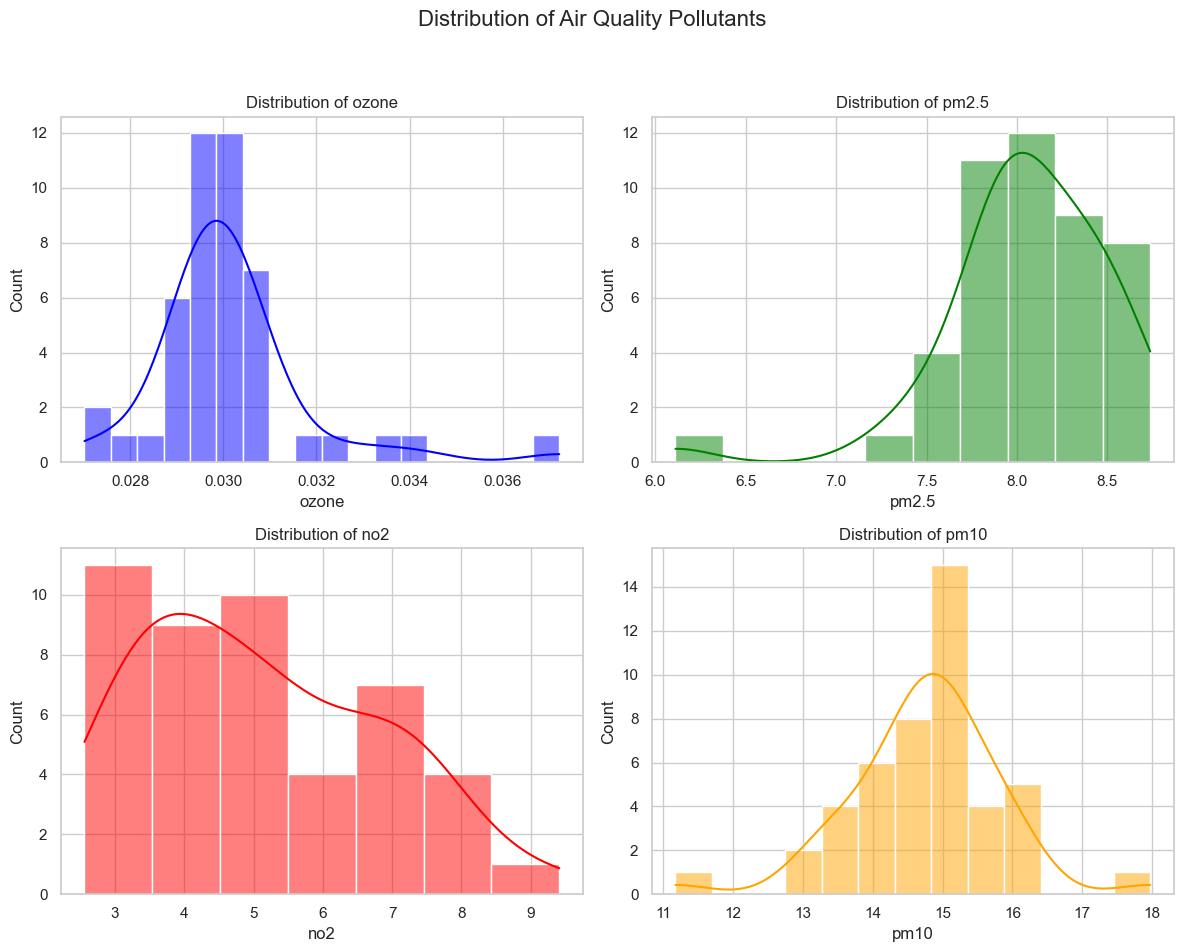

In [31]:
# ---------- Step 6.3: EDA Univariate Analysis ----------

sns.set_theme(style="whitegrid")

# Histograms and Kernel Density Estimation (Univariate Analysis)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Distribution of Air Quality Pollutants', fontsize=16)

cols = ['ozone', 'pm2.5', 'no2', 'pm10']
colors = ['blue', 'green', 'red', 'orange']

for i, col in enumerate(cols):
    ax = axes[i//2, i%2]                                                # Select the appropriate subplot
    sns.histplot(ml_eda_df[col], kde=True, ax=ax, color=colors[i])      # Plot histogram with KDE overlay
    ax.set_title(f'Distribution of {col}')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])                               # Adjust layout to make room for the main title
plt.show()

--- SC Environmental Health Correlation Matrix ---
asthma_rate      1.000
ped_E_MINRTY     0.669
ped_RPL_SVM      0.605
ped_E_POV200     0.600
ped_E_NOINT      0.594
ped_E_MOBILE     0.593
ped_E_HOUBDN     0.583
ped_E_UNEMP      0.581
ped_E_DISABL     0.544
ped_E_UNINSUR    0.525
RUCC_2023        0.502
avg_temp         0.465
ped_E_RENTER     0.457
ped_E_GROUPQ     0.367
pm10             0.339
pm2.5            0.228
ped_E_LIMENG    -0.113
ped_E_ROAD      -0.116
ozone           -0.296
Name: asthma_rate, dtype: float64


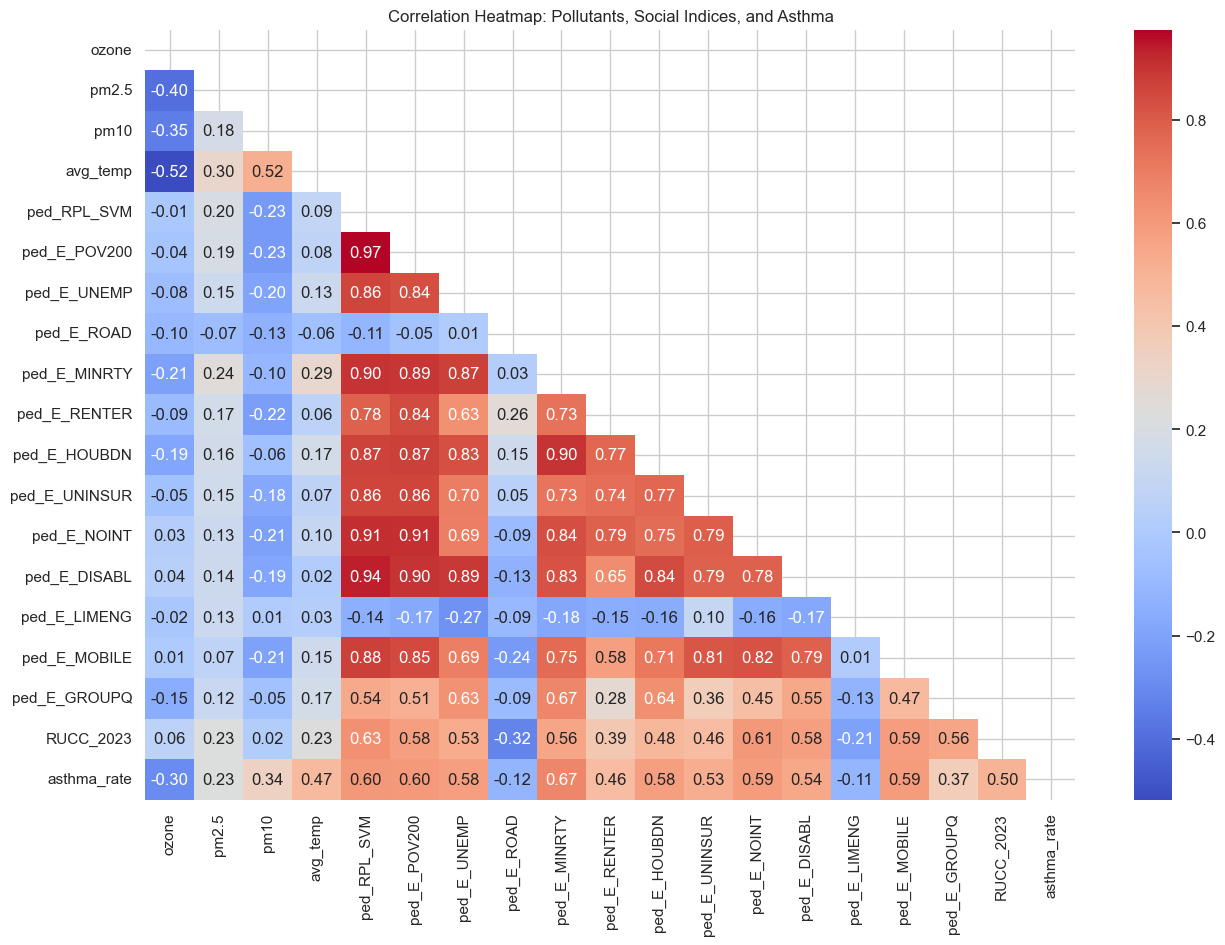

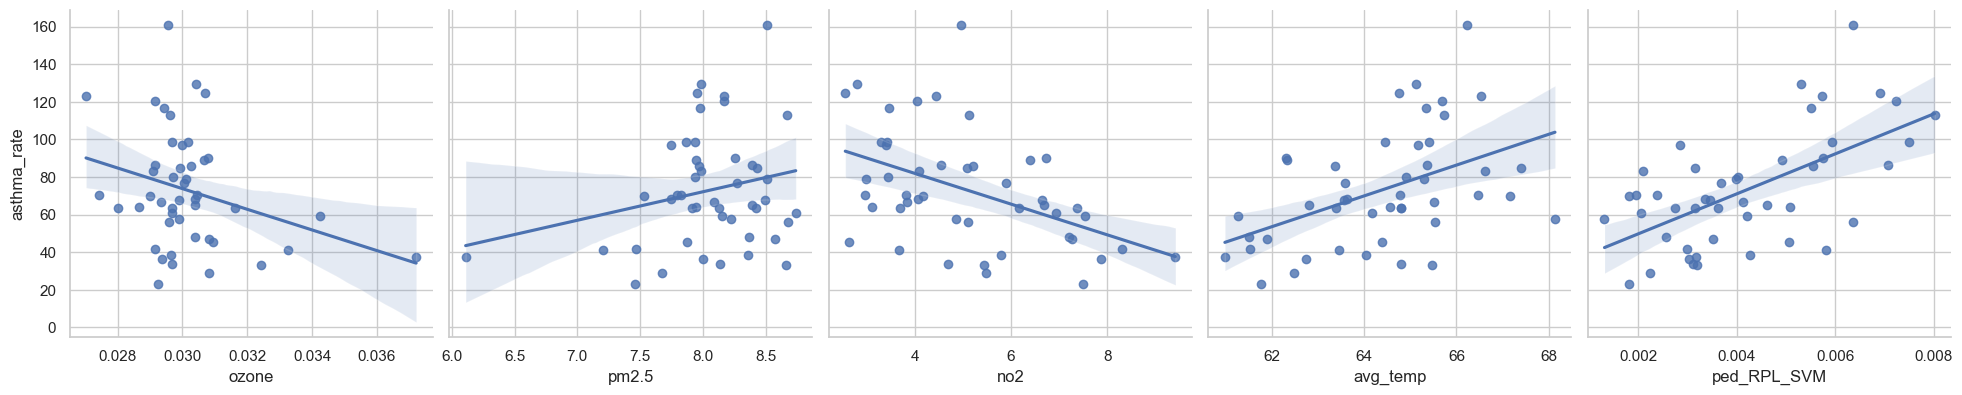

In [32]:
# ---------- Step 6.4: EDA Correlation Analysis ----------

# Note: There is currently a high dimensionality with the social vulnerability indicators, 
# so we will focus on the correlations with the asthma rates to identify potential predictors and redundancies.

# Correlation Matrix (Focus on Asthma Rates)
analysis_cols = [
    'ozone', 'pm2.5', 'pm10', 'avg_temp', 'ped_RPL_SVM', 
    'ped_E_POV200', 'ped_E_UNEMP', 'ped_E_ROAD', 'ped_E_MINRTY', 'ped_E_RENTER', 
    'ped_E_HOUBDN', 'ped_E_UNINSUR', 'ped_E_NOINT', 'ped_E_DISABL', 
    'ped_E_LIMENG', 'ped_E_MOBILE', 'ped_E_GROUPQ',
    'RUCC_2023', 'asthma_rate',
]

corr_matrix = ml_df[analysis_cols].corr().round(3)                  # Round to 3 decimal places for readability

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))               # As requested, mask the upper triangle to focus on unique pairs and reduce clutter

print("--- SC Environmental Health Correlation Matrix ---")
print(corr_matrix['asthma_rate'].sort_values(ascending=False))      # Sorted from highest to lowest correlation

# Correlation Heatmap (Identify Redundancies & Predictors)
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap: Pollutants, Social Indices, and Asthma")
plt.show()

# Pairplot (Visual Scan of Distributions and Scatters)
# Focusing on the Target (asthma_rate)
sns.pairplot(ml_df, y_vars=['asthma_rate'], x_vars=['ozone', 'pm2.5', 'no2', 'avg_temp', 'ped_RPL_SVM'], 
             kind='reg', height=4)
plt.show()


#### **Correlation Matrix Findings**

**High Redundancy (Multicollinearity)**
* ped_RPL_SVM and its components: As SVM is a composite index, it correlates almost perfectly with its parts. 
* ped_E_NOINT and ped_E_POV200 (0.91): Lack of internet and poverty are highly confounded in this dataset.
* ped_E_HOUBDN and ped_E_MINRTY (0.90): Minority status and housing burden are showing extreme overlap.

**Low Predictive Value**
* ped_E_LIMENG (-0.11): Limited English proficiency has the lowest correlation with asthma rates in this set.
* ped_E_ROAD (-0.12): Proximity to roads (as weighted here) shows almost no linear relationship with the target.
* ozone (-0.30): While higher than the others, its negative correlation is counter-intuitive for asthma and might be confounded by geography or temperature.


--- Final Features for Modeling ---
Index(['pm10', 'avg_temp', 'ped_E_RENTER', 'ped_E_MOBILE', 'ped_E_GROUPQ',
       'RUCC_2023', 'asthma_rate'],
      dtype='object')


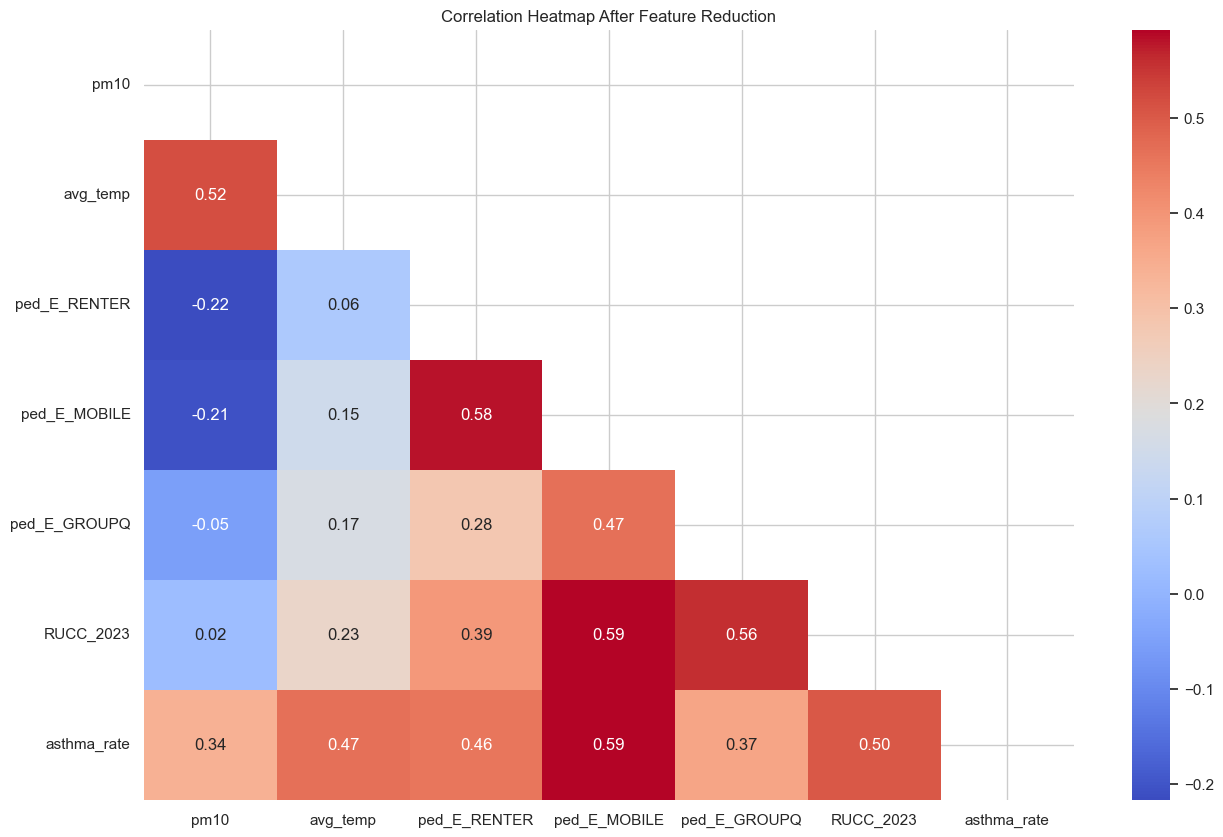

In [33]:
# ---------- Step 6.5: Final Feature Selection ----------
# Will drop irrelevant features, redundant features, and ozone due to low correlation and potential outlier influence.
# After conducting multiple VIF iterations, below are the final features retained for modeling.

ml_df2 = ml_df[['pm10', 'avg_temp', 
    'ped_E_RENTER', 'ped_E_MOBILE', 'ped_E_GROUPQ', 'RUCC_2023', 'asthma_rate']].copy()

print("--- Final Features for Modeling ---")
print(ml_df2.columns)

# Mask
mask = np.triu(np.ones_like(ml_df2.corr(), dtype=bool))

# Correlation Heatmap (Identify Redundancies & Predictors)
plt.figure(figsize=(15, 10))
sns.heatmap(ml_df2.corr(), mask=mask, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap After Feature Reduction")
plt.show()


In [34]:
# ---------- Step 6.6: VIF Calculation ----------
# Finalized Feature Selection
final_features = ml_df2[[
    'pm10', 'avg_temp', 
    'ped_E_RENTER', 'ped_E_MOBILE', 'ped_E_GROUPQ', 'RUCC_2023'
]]

# Add the constant
final_features_const = sm.add_constant(final_features)

# VIF Calculation
vif_final = pd.DataFrame()
vif_final["feature"] = final_features_const.columns
vif_final["VIF"] = [variance_inflation_factor(final_features_const.values, i) 
                     for i in range(len(final_features_const.columns))]

print("--- Final VIF Report ---")
print(vif_final.sort_values(by="VIF", ascending=False))


--- Final VIF Report ---
        feature          VIF
0         const  1535.580757
4  ped_E_MOBILE     2.147431
6     RUCC_2023     1.902549
1          pm10     1.592704
3  ped_E_RENTER     1.548613
2      avg_temp     1.533996
5  ped_E_GROUPQ     1.527125


In [35]:
# ---------- Step 6.7: Alternate Feature Engineering ----------
ml_df3 = ml_df2.copy() 

# Create a composite Housing Vulnerability feature by summing weighted indices related to housing vulnerability
ml_df3['ped_TOTAL_HOUSING_VULN'] = (
    ml_df3['ped_E_RENTER'] + 
    ml_df3['ped_E_MOBILE'] + 
    ml_df3['ped_E_GROUPQ']
)

# Dummy code for urban influence 
# (will be used in the model to control for urbanicity)
ml_df3 = ml_df3.merge(sc_urban_RUCC[['FIPS', 'urban_influence']], on='FIPS', how='left')

# Generate the dummies, prefix='loc' to keep the column names clean
ml_df3 = pd.get_dummies(ml_df3, columns=['urban_influence'], prefix='loc')

# Display the new columns to confirm
print("\n--- Urban Features Added ---")
new_cols = [c for c in ml_df3.columns if c.startswith('loc_')]
print(ml_df3[new_cols].head())

ml_df3.head(1)


--- Urban Features Added ---
   loc_Metro  loc_Rural-Adjacent  loc_Rural-Isolated
0       True               False               False
1      False                True               False
2       True               False               False
3       True               False               False
4       True               False               False


,FIPS,pm10,avg_temp,ped_E_RENTER,ped_E_MOBILE,ped_E_GROUPQ,RUCC_2023,asthma_rate,ped_TOTAL_HOUSING_VULN,loc_Metro,loc_Rural-Adjacent,loc_Rural-Isolated
0,45091,13.877455,61.760185,0.122205,0.044068,0.012778,1,22.921037,0.179051,True,False,False


# **Part 7:** Modeling


**Discussion:** Due to the sparsity of 46 instances/datapoints; using Leave one out cross validation (LOOCV) to allow the model a chance to learn. LOOCV trains on 45 counties and tests on one county (repeating 46 times to allow each county to be tested).

In [36]:
######## Primary: pm10, avg_temp, ped_TOTAL_HOUSING_VULN, RUCC_2023, loc_Rural-Isolated ########

ml_df4 = ml_df3.copy()

hybrid_features = [
    'pm10', 
    'avg_temp', 
    'ped_TOTAL_HOUSING_VULN', 
    'RUCC_2023',           # Rank (VIF confirms this is safe, previous iterations showed that this reinforces the rural-urban gradient and captures the risks of both urban and rural counties, thus we will keep it in the model)
    'loc_Rural-Isolated'   # Dummy variable captures the risks of the most isolated rural counties
]

X = ml_df4[hybrid_features]
y = ml_df4['asthma_rate']
y_log = np.log1p(y)

# 3. Re-run scaling and LOO
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X)
loo = LeaveOneOut()         # Reminder: LOO is ideal for small datasets, as it maximizes training data while providing an unbiased evaluation for each observation!

# ---------- Step 7.1.2: Tuning GridSearchCV ----------
# Note: We will tune the Random Forest model as it is the most complex and has the most hyperparameters, while Huber and Bayesian Ridge are more straightforward with fewer parameters to tune.
param_grid = {
    'n_estimators': [50, 100],          # Number of trees in the forest, more trees can improve performance but also increase computation time...
    'max_depth': [2, 3, 4],             # Max tree depth, controls how deep the tree can grow, deeper trees can capture more complex patterns but may overfit
    'min_samples_leaf': [2, 3, 5],      # Min number of samples required to be at a leaf node, higher values can prevent overfitting by ensuring that leaf nodes have more samples
    'max_features': ['sqrt', 0.5, 1.0]  # Number of features to consider when looking for the best split, 'sqrt' is a common choice for regression tasks, while 0.5 and 1.0 is to explore using half or all features
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),   # RF is an ensemble method that captures non-linear relationships and interactions between features
    param_grid=param_grid,                              # Grid of hyperparameters to search over
    cv=loo,                                             # Reminder: LOO is ideal for small datasets, as it maximizes training data while providing an unbiased evaluation for each observation!
    scoring='neg_mean_absolute_error',                  # MAE is a common metric for regression tasks, and using negative MAE allows GridSearchCV to maximize the score (as it tries to find the best parameters that minimize MAE)
    n_jobs=-1                                           # Use all available cores for parallel processing to speed up the grid search, especially important given the computational intensity of LOO with multiple hyperparameter combinations
)

grid_search.fit(X_scaled, y_log)                        # Fit the grid search to the data, which will train a Random Forest model for each combination of hyperparameters and evaluate it using LOO cross-validation, ultimately finding the best set of hyperparameters based on the lowest MAE.
best_rf = grid_search.best_estimator_                   # Extract the best Random Forest model with the optimal hyperparameters found by GridSearchCV

print(f"Optimized RF Parameters: {grid_search.best_params_}\n")

# ---------- Step 7.1.3: Define Main Models ----------
models = {
    "Huber_Robust (Champion)": HuberRegressor(epsilon=1.35),    # Huber: Robust to outliers (treats high residuals linearly instead of quadratically)
    "Bayesian_Ridge": BayesianRidge(),                          # Bayesian Ridge: Automatically tunes its own regularization
    "Random Forest (Tuned)": best_rf                            # Random Forest: Captures non-linear relationships and interactions, with tuned hyperparameters
    }
# ---------- Step 7.1.4: Evaluate and Compare ----------
results = {}

print("--- Model Performance Comparison (MAE) ---")
for name, model in models.items():
    # Predict in log-space using LOO
    log_preds = cross_val_predict(model, X_scaled, y_log, cv=loo)
    # Convert back to real asthma cases per 10k
    real_preds = np.expm1(log_preds)
    
    mae = mean_absolute_error(y, real_preds)
    results[name] = mae
    print(f"{name}: {mae:.2f} cases/10k")

# ---------- Step 7.1.5: Extract Champion Model for Plotting ----------
# Automatically picks whichever model had the lowest MAE from the results dictionary
winner_name = min(results, key=results.get)
winner_model = models[winner_name]

winner_log_preds = cross_val_predict(winner_model, X_scaled, y_log, cv=loo)
ml_df3['Final_Predicted_Rate'] = np.expm1(winner_log_preds)

print(f"\n Overall Champion Model for Plotting: {winner_name}")


Optimized RF Parameters: {'max_depth': 3, 'max_features': 1.0, 'min_samples_leaf': 5, 'n_estimators': 50}

--- Model Performance Comparison (MAE) ---
Huber_Robust (Champion): 17.79 cases/10k
Bayesian_Ridge: 15.67 cases/10k
Random Forest (Tuned): 18.50 cases/10k

 Overall Champion Model for Plotting: Bayesian_Ridge


In [37]:
######## Secondary Attempt: pm10, avg_temp, ped_E_RENTER, ped_E_MOBILE, ped_E_GROUPQ, RUCC_2023, loc_Rural-Isolated ########

# Note: This is a secondary attempt to explore a more granular feature set without the composite housing vulnerability feature, to see if the model performance improves or worsens.

ml_df5 = ml_df3.copy()
hybrid_features2 = [
    'pm10', 'avg_temp', 'RUCC_2023', 'loc_Rural-Isolated',
    'ped_E_RENTER',	'ped_E_MOBILE',	'ped_E_GROUPQ'
]

X2 = ml_df5[hybrid_features2]
y2 = ml_df5['asthma_rate']
y_log2 = np.log1p(y2)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() 
X_scaled2 = scaler.fit_transform(X2)
loo = LeaveOneOut()

# ---------- Step 7.1.2: Tuning GridSearchCV ----------
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [2, 3, 4],
    'min_samples_leaf': [2, 3, 5],
    'max_features': ['sqrt', 0.5, 1.0]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=loo, 
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid_search.fit(X_scaled2, y_log2)
best_rf2 = grid_search.best_estimator_

print(f"Optimized RF Parameters: {grid_search.best_params_}\n")

# ---------- Step 7.1.3: Define Main Models ----------
models = {
    "Huber_Robust": HuberRegressor(epsilon=1.35),
    "Bayesian_Ridge (Champion)": BayesianRidge(), 
    "Random Forest (Tuned)": best_rf2 
    }
# ---------- Step 7.1.4: Evaluate and Compare ----------
results2 = {}

print("--- Model Performance Comparison (MAE) ---")
for name, model in models.items():
    log_preds2 = cross_val_predict(model, X_scaled2, y_log2, cv=loo)
    real_preds2 = np.expm1(log_preds2)
    mae2 = mean_absolute_error(y2, real_preds2)
    results2[name] = mae2
    print(f"{name}: {mae2:.2f} cases/10k")

# ---------- Step 7.1.5: Extract Champion Model for Plotting ----------
winner_name2 = min(results2, key=results2.get)
winner_model2 = models[winner_name2]
winner_log_preds2 = cross_val_predict(winner_model2, X_scaled2, y_log2, cv=loo)
ml_df5['Final_Predicted_Rate'] = np.expm1(winner_log_preds2)

print(f"\n Overall Champion Model for Plotting: {winner_name2}")



Optimized RF Parameters: {'max_depth': 4, 'max_features': 1.0, 'min_samples_leaf': 2, 'n_estimators': 50}

--- Model Performance Comparison (MAE) ---
Huber_Robust: 18.66 cases/10k
Bayesian_Ridge (Champion): 16.22 cases/10k
Random Forest (Tuned): 18.19 cases/10k

 Overall Champion Model for Plotting: Bayesian_Ridge (Champion)


In [38]:
# ---------- Step 7.1.6: Analyze Feature Contributions ----------
# While the composite housing vulnerability feature (ped_TOTAL_HOUSING_VULN) had better MAE, the separated features allow us 
# to identify which specific sub-features (renting, mobile homes, group quarters) are most strongly associated with asthma rates.

# Check which sub-feature is driving the Vulnerability signal
housing_sub_features = ['ped_E_RENTER', 'ped_E_MOBILE', 'ped_E_GROUPQ']
correlations = ml_df5[housing_sub_features + ['asthma_rate']].corr()['asthma_rate'] 
print("--- Housing Drivers of Asthma ---")
print(correlations.sort_values(ascending=False))

# Check if Mobile Homes and Rural Isolation are just the same thing
correlation_check = ml_df5[['ped_E_MOBILE', 'loc_Rural-Isolated', 'RUCC_2023']].corr()
print(correlation_check)


--- Housing Drivers of Asthma ---
asthma_rate     1.000000
ped_E_MOBILE    0.592594
ped_E_RENTER    0.456699
ped_E_GROUPQ    0.367132
Name: asthma_rate, dtype: float64
                    ped_E_MOBILE  loc_Rural-Isolated  RUCC_2023
ped_E_MOBILE            1.000000            0.076806   0.589576
loc_Rural-Isolated      0.076806            1.000000   0.317112
RUCC_2023               0.589576            0.317112   1.000000


In [39]:
# ---------- Step 7.2: Model Comparison ----------

# Define Models
comparison_models = {
    "Huber_Robust": HuberRegressor(epsilon=1.35),                   # Epsilon of 1.35 is a common choice that balances sensitivity to outliers while still capturing the overall trend in the data, but this can be further tuned if desired.
    "Bayesian_Ridge": BayesianRidge(),
    "Random Forest (Tuned)": best_rf                                # Plugs in GridSearch winner
}

results_summary = []

for name, model in comparison_models.items():
    # --- TRAINING ERROR ---
    # Fit and predict on the exact same data (shows how much the model 'memorized')
    model.fit(X_scaled, y_log)
    train_log_preds = model.predict(X_scaled)
    train_preds = np.expm1(train_log_preds)
    train_mae = mean_absolute_error(ml_df3['asthma_rate'], train_preds)
    
    # --- TEST ERROR (LOO) ---
    # Predict for each county when it was 'unseen' by the model 
    test_log_preds = cross_val_predict(model, X_scaled, y_log, cv=loo)
    test_preds = np.expm1(test_log_preds)                                   # Convert back to real asthma rates 
    test_mae = mean_absolute_error(ml_df3['asthma_rate'], test_preds)
    
    # --- CALCULATE THE OVERFIT GAP ---
    gap = test_mae - train_mae
    
    results_summary.append({
        "Model": name,
        "Train MAE": round(train_mae, 2),                                   # Training error (how well the model fits the data it was trained on)
        "Test MAE (LOO)": round(test_mae, 2),                               # Test error (how well the model generalizes to unseen data, lower is better)
        "Gap (Overfit)": round(gap, 2)                                      # The difference between test and train error, a smaller gap indicates better generalization and less overfitting
    })

# Display Side-by-Side Comparison
summary_df = pd.DataFrame(results_summary).sort_values(by="Test MAE (LOO)")

print("\n--- Final Comparison ---")
print(summary_df.to_string(index=False))                                    # Display the summary dataframe without the index for cleaner presentation
best_model_name = summary_df.iloc[0]['Model']                               # The model with the lowest Test MAE (LOO) is considered the best for our purposes, as it indicates the best generalization to unseen data
best_gap = summary_df.iloc[0]['Gap (Overfit)']                              # A stable generalization gap (not too large) suggests that the model is not overfitting and is likely to perform well on new data
print(f"\nFinal Choice: {best_model_name}")
print(f"Rationale: Lowest Test error with a stable generalization gap of {best_gap}.")




--- Final Comparison ---
                Model  Train MAE  Test MAE (LOO)  Gap (Overfit)
       Bayesian_Ridge      13.91           15.67           1.76
         Huber_Robust      14.03           17.79           3.76
Random Forest (Tuned)      14.19           18.50           4.31

Final Choice: Bayesian_Ridge
Rationale: Lowest Test error with a stable generalization gap of 1.76.


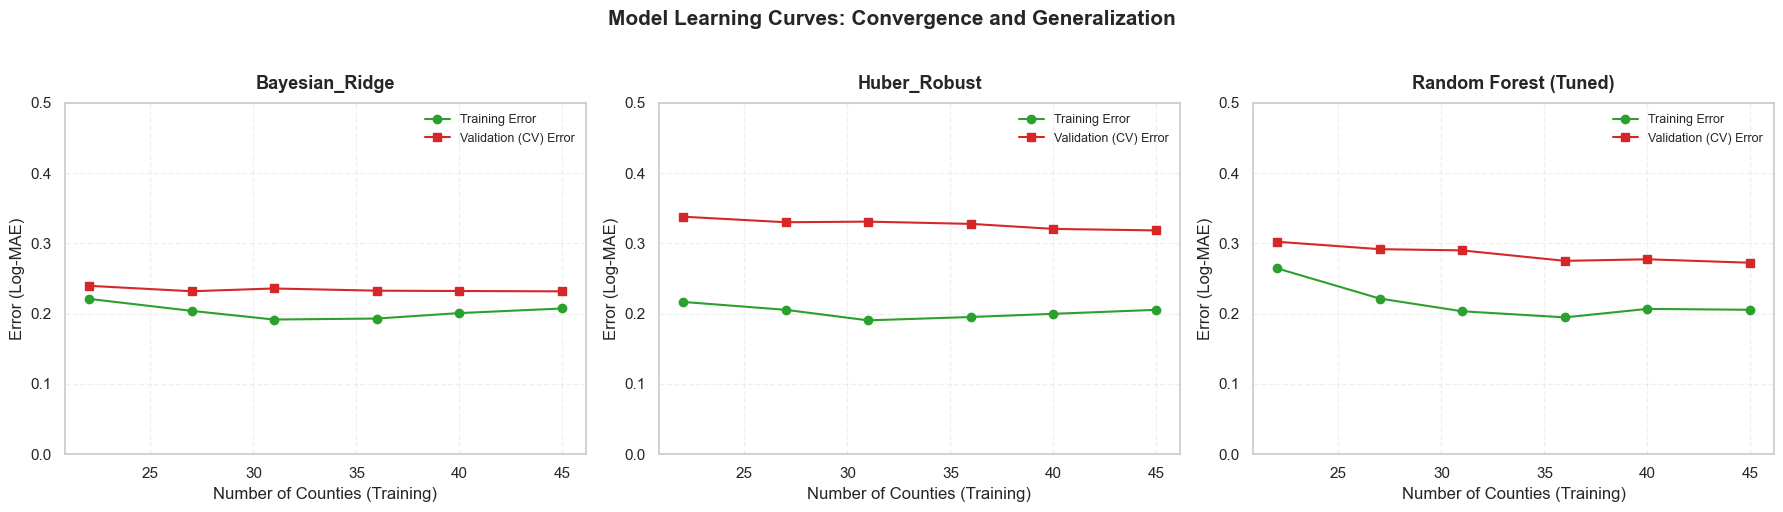

In [40]:
# ---------- Step 7.3: Generate Learning Curves (Bayesian Ridge) ----------

# Finalize Data (using log-transform to match successful training)
features = ['pm10', 'avg_temp', 
            'ped_TOTAL_HOUSING_VULN', 'RUCC_2023', 'loc_Rural-Isolated']

X_final = ml_df4[features].values
y_log_final = np.log1p(ml_df4['asthma_rate']).values

# Re-Scale (For Bayesian Ridge and Huber)
scaler = StandardScaler()
X_scaled_final = scaler.fit_transform(X_final)

# Define Models 
comparison_models = {
    "Bayesian_Ridge": BayesianRidge(),
    "Huber_Robust": HuberRegressor(epsilon=1.35, max_iter=1000),
    "Random Forest (Tuned)": best_rf 
}

# Setup Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()
loo = LeaveOneOut() # Ideal for n=46

for i, (name, model) in enumerate(comparison_models.items()):
    # Using 50% to 100% of samples
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_scaled_final, y_log_final, 
        cv=loo, 
        scoring='neg_mean_absolute_error',              # Using negative MAE allows learning_curve to maximize the score (as it tries to find the best training sizes that minimize MAE)
        train_sizes=np.linspace(0.5, 1.0, 6),           # 50% to 100% of the data in 6 increments
        n_jobs=-1                                       # Use all cores for parallel processing to speed up the learning curve computation, especially important given the computational intensity of LOO with multiple training sizes
    )

    # Convert negative MAE to positive
    train_mean = -np.mean(train_scores, axis=1) 
    test_mean = -np.mean(test_scores, axis=1)

    # Plotting logic
    axes[i].plot(train_sizes, train_mean, 'o-', color="#2ca02c", label="Training Error")
    axes[i].plot(train_sizes, test_mean, 's-', color="#d62728", label="Validation (CV) Error")
    
    axes[i].set_title(name, fontsize=13, fontweight='bold', pad=10)
    axes[i].set_xlabel("Number of Counties (Training)")
    axes[i].set_ylabel("Error (Log-MAE)")
    axes[i].legend(loc="upper right", fontsize=9)
    axes[i].grid(True, linestyle='--', alpha=0.3)
    
    # Standardize y-axis across all three for fair visual comparison
    axes[i].set_ylim(0, max(test_mean.max() * 1.2, 0.5)) 

plt.suptitle("Model Learning Curves: Convergence and Generalization", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


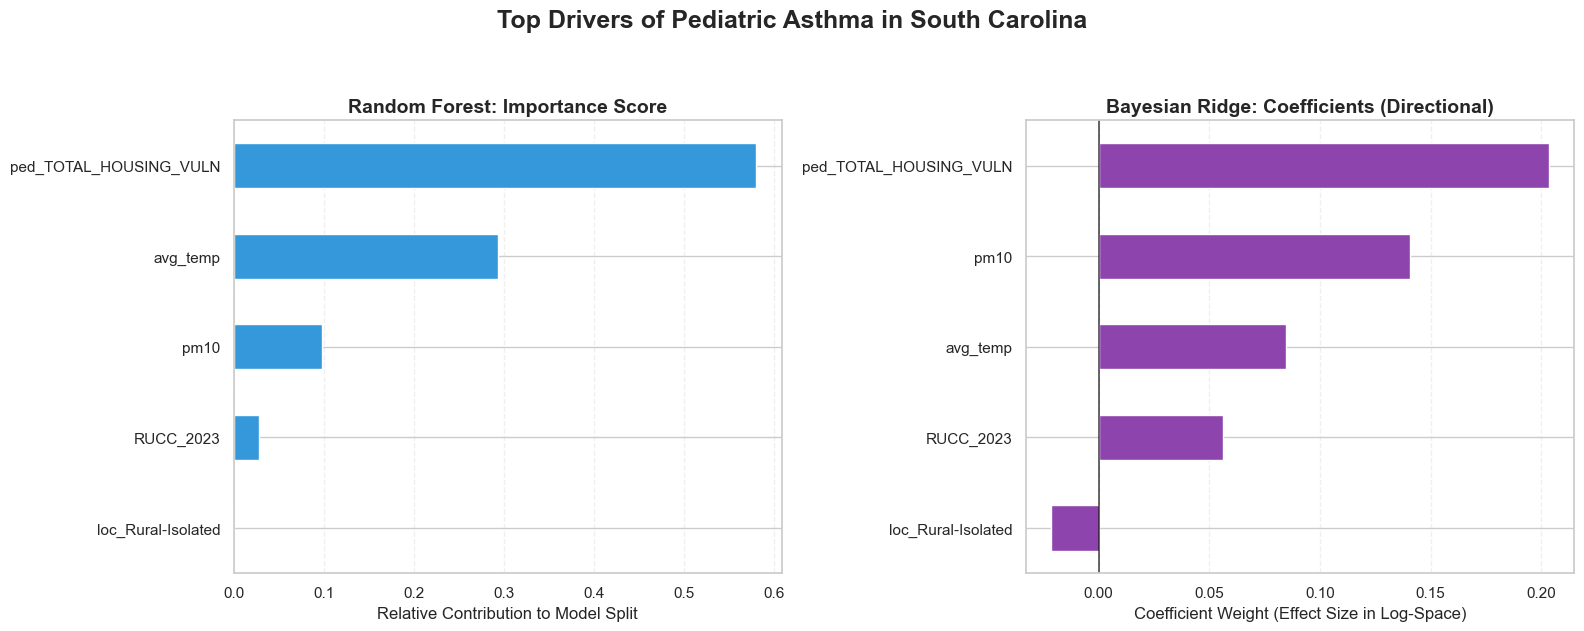


--- Bayesian Ridge Feature Weights ---
ped_TOTAL_HOUSING_VULN    0.203464
pm10                      0.140751
avg_temp                  0.084788
RUCC_2023                 0.056377
loc_Rural-Isolated       -0.021686
dtype: float64


In [41]:
# ---------- Step 7.4: Feature Importance and Coefficient Analysis (Bayesian) ----------

# Fit the Bayesian Ridge Model
champion_model = BayesianRidge()
champion_model.fit(X_scaled, y_log)

# Setup Plotting (RF Importance vs Bayesian Weights)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- PLOT 1: Random Forest (Non-Linear Importance) ---
# Importance is always positive; shows which variables the forest "uses" most.
rf_importances = pd.Series(best_rf.feature_importances_, index=features).sort_values(ascending=True)
rf_importances.plot(kind='barh', color='#3498db', ax=axes[0])                                           # kind='barh' for horizontal bars, color changed to Blue for RF
axes[0].set_title('Random Forest: Importance Score', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Relative Contribution to Model Split')
axes[0].grid(axis='x', linestyle='--', alpha=0.3)

# --- PLOT 2: Bayesian Ridge Champion (Linear Directional Effect) ---
# Coefficients show the direction (Positive = Increases Asthma, Negative = Decreases)
bayesian_coefs = pd.Series(champion_model.coef_, index=features).sort_values(ascending=True)
bayesian_coefs.plot(kind='barh', color='#8e44ad', ax=axes[1]) 
axes[1].set_title('Bayesian Ridge: Coefficients (Directional)', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Coefficient Weight (Effect Size in Log-Space)')

# Add a vertical line at zero to clearly separate "Drivers" from "Protectors"
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=1.2, alpha=0.7)
axes[1].grid(axis='x', linestyle='--', alpha=0.3)

plt.suptitle('Top Drivers of Pediatric Asthma in South Carolina', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# Print the exact weights for report
print("\n--- Bayesian Ridge Feature Weights ---")
print(bayesian_coefs.sort_values(ascending=False))


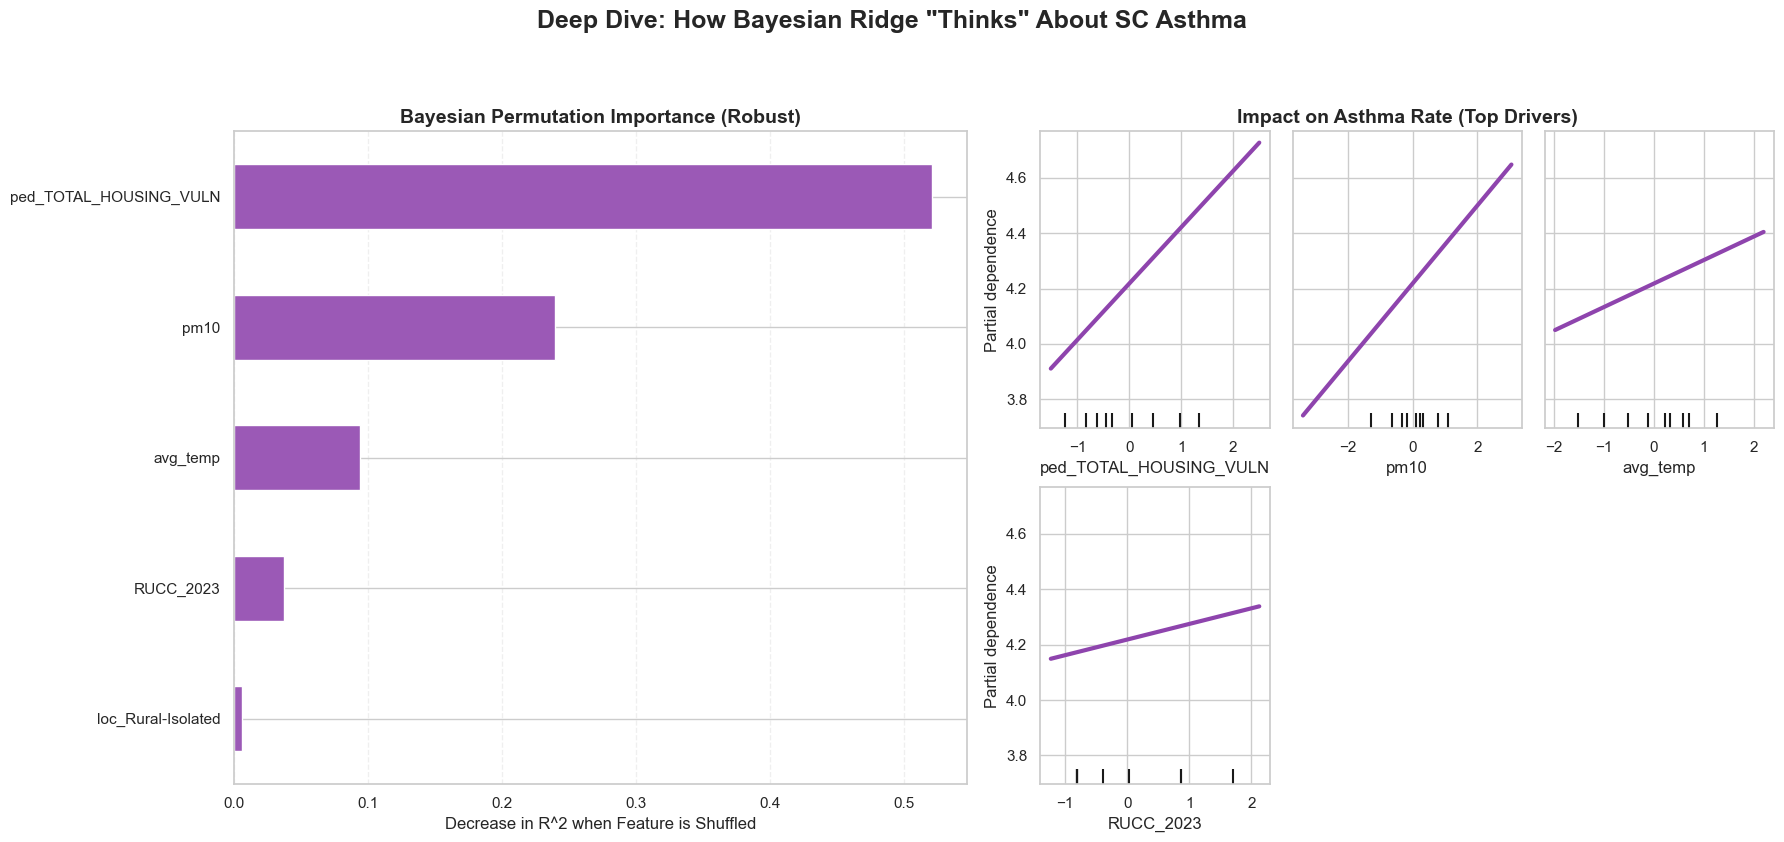

In [42]:
# ---------- Step 7.5.1: Permutation Importance (Bayesian) ----------
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from sklearn.inspection import permutation_importance, PartialDependenceDisplay
# Using the scaled DataFrame for PDP labeling
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

# Calculate Permutation Importance for Bayesian Ridge
# This measures how much the model's R-squared drops when a feature is "broken" (shuffled)
perm_importance = permutation_importance(
    champion_model, X_scaled, y_log, n_repeats=50, random_state=42 
)

# Organize results
perm_df = pd.Series(perm_importance.importances_mean, index=features).sort_values(ascending=True)

# Setup Interpretation Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# --- PLOT 1: Permutation Importance ---
# Which features are load-bearing for Bayesian model
perm_df.plot(kind='barh', color='#9b59b6', ax=ax1)
ax1.set_title('Bayesian Permutation Importance (Robust)', fontweight='bold', fontsize=14)
ax1.set_xlabel('Decrease in R^2 when Feature is Shuffled')
ax1.grid(axis='x', linestyle='--', alpha=0.3)

# --- PLOT 2: Partial Dependence ---
# Top 4 most important features from the perm_df
top_4_features = perm_df.sort_values(ascending=False).index[:4].tolist()

PartialDependenceDisplay.from_estimator(
    champion_model, 
    X_scaled_df, 
    features=top_4_features, 
    ax=ax2,
    line_kw={"color": "#8e44ad", "linewidth": 3} 
)
ax2.set_title('Impact on Asthma Rate (Top Drivers)', fontweight='bold', fontsize=14)

plt.suptitle('Deep Dive: How Bayesian Ridge "Thinks" About SC Asthma', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


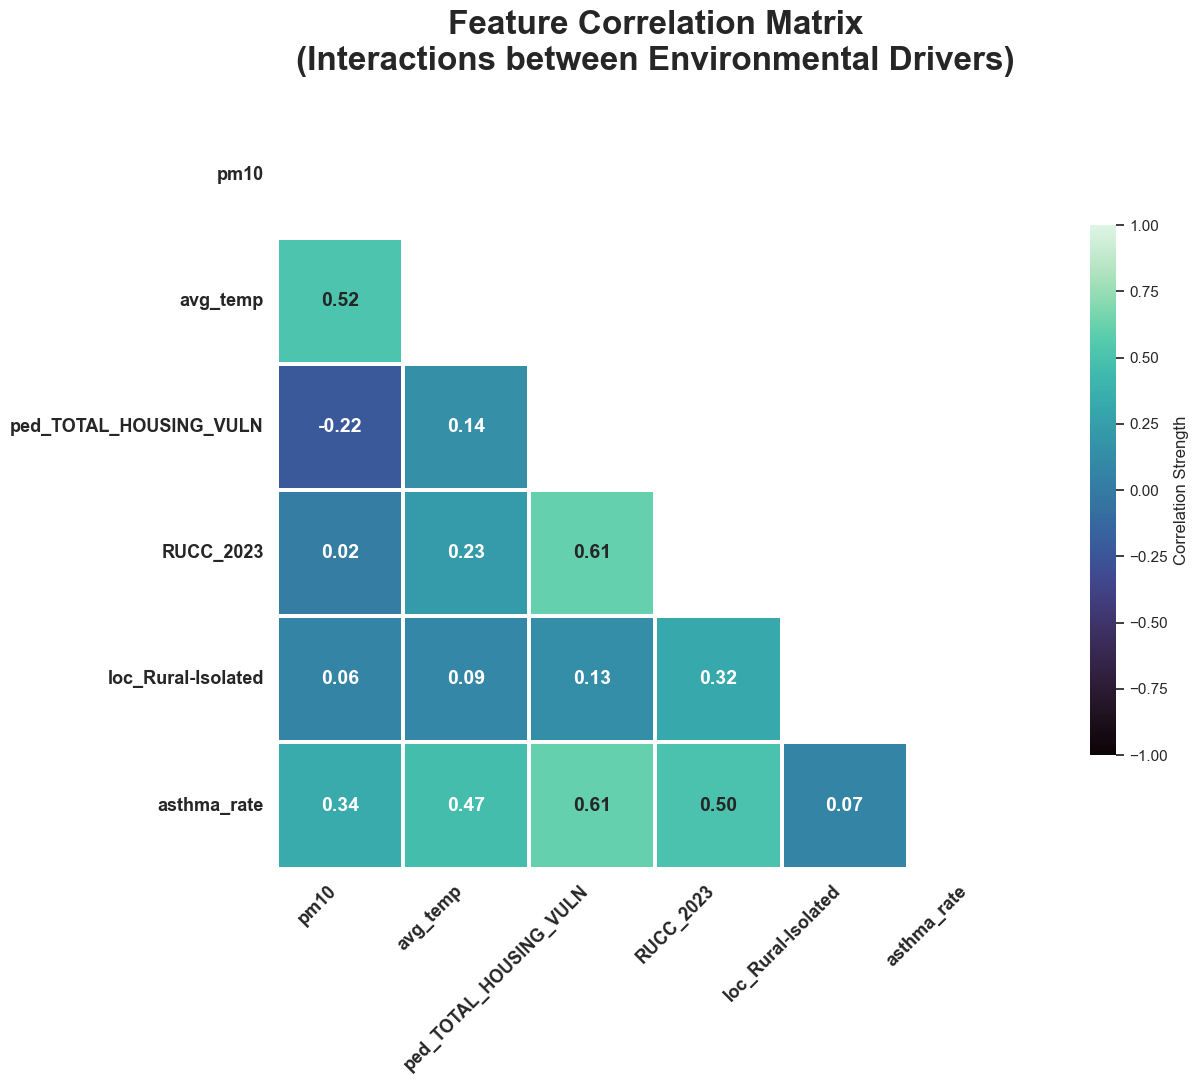

In [43]:
# ---------- Step 7.6: Visualization ----------

import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Setup
plt.figure(figsize=(14, 11))
sns.set_style("white")

# Correlation Matrix
corr_matrix = ml_df4[features + ['asthma_rate']].corr()

# Mask the upper triangle so only the bottom-left remains
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot
heatmap = sns.heatmap(
    corr_matrix, 
    mask=mask,              # Apply the mask to show only the lower triangle
    annot=True,            
    fmt=".2f",             
    cmap='mako',       
    vmin=-1, vmax=1,       
    center=0,
    square=True,           
    linewidths=1.5,         # Thicker lines for better separation
    cbar_kws={"shrink": .7, "label": "Correlation Strength"},
    annot_kws={"size": 14, "weight": "bold"} # Bigger numbers for the poster
)

# Labels
plt.title('Feature Correlation Matrix\n(Interactions between Environmental Drivers)', 
          fontsize=24, fontweight='bold', pad=30)

# Rotate labels
plt.xticks(rotation=45, ha='right', fontsize=13, fontweight='bold')
plt.yticks(rotation=0, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


In [44]:
# ---------- Step 7.7: Prep for GIS CSV ----------

# Update the winner_model to BayesianRidge and ensure it is fit
winner_model = BayesianRidge()
winner_model.fit(X_scaled, y_log)

# Merge County Names for readability
# Assuming sc_county_code_df is your mapping dataframe
ml_df4 = ml_df4.merge(sc_county_code_df[['FIPS', 'County Name']], on='FIPS', how='left', suffixes=('', '_drop'))

# Generate the Predictions
# Predict in log-space, then use expm1 to get back to real asthma cases per 10k
final_log_preds = winner_model.predict(X_scaled)
ml_df4['ML_Predicted_Asthma'] = np.expm1(final_log_preds)

# Residual Analysis
# Positive Residual = Under-prediction (Actual > Predicted)
# Negative Residual = Over-prediction (Actual < Predicted)
ml_df4['Residual'] = ml_df4['asthma_rate'] - ml_df4['ML_Predicted_Asthma']
ml_df4['Abs_Error'] = ml_df4['Residual'].abs()

# Identify Outliers
under_preds = ml_df4.sort_values(by='Residual', ascending=False).head(3)
over_preds = ml_df4.sort_values(by='Residual', ascending=True).head(3)

print("--- Top 3 Under-Predictions (Model was too LOW) ---")
print(under_preds[['County Name', 'asthma_rate', 'ML_Predicted_Asthma', 'Residual']])

print("\n--- Top 3 Over-Predictions (Model was too HIGH) ---")
print(over_preds[['County Name', 'asthma_rate', 'ML_Predicted_Asthma', 'Residual']])


--- Top 3 Under-Predictions (Model was too LOW) ---
   County Name  asthma_rate  ML_Predicted_Asthma   Residual
21     hampton   161.056689           112.908379  48.148310
34     chester    88.902429            49.932498  38.969931
13      marion   129.205121            93.671090  35.534030

--- Top 3 Over-Predictions (Model was too HIGH) ---
   County Name  asthma_rate  ML_Predicted_Asthma   Residual
40    barnwell    55.885780           103.855815 -47.970035
44       aiken    33.246015            60.523793 -27.277778
14   lexington    33.730168            58.890821 -25.160654


In [45]:
# ---------- Step 7.8: Generate ArcGIS-Ready Results (Bayesian Ridge) ----------

# BayesianRidge (The 15.67 MAE winner)
winner_model = BayesianRidge()

# Out-of-Sample Predictions using Leave-One-Out (LOO)
# This uses the hybrid features and scaling established earlier
loo = LeaveOneOut()
test_log_preds = cross_val_predict(winner_model, X_scaled, y_log, cv=loo)

# Transform predictions back to real-world units (Cases per 10k)
ml_df6 = ml_df4.copy()
ml_df6['Test_Predicted_Rate'] = np.expm1(test_log_preds) # np.expm1 reverses the log1p transformation

# Calculate Absolute Error and Percentage Error for ArcGIS mapping
ml_df6['Test_Abs_Error'] = np.abs(ml_df6['asthma_rate'] - ml_df6['Test_Predicted_Rate'])
ml_df6['Error_Percentage'] = (ml_df6['Test_Abs_Error'] / ml_df6['asthma_rate']) * 100

# Validation Print
print(f"--- Export Complete: SC_Asthma_ML_Results_CAO27Mar.csv ---")
print(f"Verified Bayesian Ridge MAE: {ml_df6['Test_Abs_Error'].mean():.2f} cases/10k")
print(f"Worst Prediction Error: {ml_df6['Test_Abs_Error'].max():.2f} cases/10k")

# Export to CSV for ArcGIS
ml_df6['FIPS'] = ml_df6['FIPS'].astype(str).str.zfill(5)    # Ensure FIPS is included as a string to preserve leading zeros
ml_df6.to_csv('SC_Asthma_ML_Results_CAO27Mar.csv', index=False)

--- Export Complete: SC_Asthma_ML_Results_CAO27Mar.csv ---
Verified Bayesian Ridge MAE: 15.67 cases/10k
Worst Prediction Error: 55.38 cases/10k
